# Импорты библиотек

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import mannwhitneyu, f_oneway, kruskal, zscore, shapiro, normaltest, pearsonr, spearmanr
from typing import Dict, List, Tuple, Optional, Any

# Чтение данных

In [2]:
df_path = "marketplace.csv"

df = pd.read_csv(df_path)

print("Первые 5 строк:")
df.head(5)

Первые 5 строк:


,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return
0,user_000000,12,2025-03-22,2024-08-17,browser_00,2025-03-22,0.0,85.329559,0.0
1,user_000001,1,2025-05-05,2025-05-15,browser_01,2025-05-20,0.0,21.819124,0.0
2,user_000002,5,2025-01-19,2025-01-23,browser_02,2025-02-20,0.3,194.612980,485.0
3,user_000003,3,2025-03-15,2023-09-05,browser_02,NaN,0.0,138.780814,0.0
4,user_000004,1,2025-05-05,2025-05-14,browser_00,2025-05-11,0.0,16.334507,0.0


In [3]:
print(f"Размер датасета: {df.shape}")
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")

Размер датасета: (25335, 9)
Количество строк: 25335
Количество столбцов: 9


In [4]:
print("Типы данных:")
df.dtypes

Типы данных:


user_id          object
platform_num      int64
first_login      object
reg_dt           object
browser          object
first_buy        object
target          float64
total_buy       float64
total_return    float64
dtype: object

In [5]:
# Приведем столбцы с датами к типу datetime
df['first_login'] = pd.to_datetime(df['first_login'])
df['reg_dt'] = pd.to_datetime(df['reg_dt'])
df['first_buy'] = pd.to_datetime(df['first_buy'])

In [6]:
df.dtypes

user_id                 object
platform_num             int64
first_login     datetime64[ns]
reg_dt          datetime64[ns]
browser                 object
first_buy       datetime64[ns]
target                 float64
total_buy              float64
total_return           float64
dtype: object

In [7]:
print("Основные статистики:")
df.describe()

Основные статистики:


,platform_num,first_login,reg_dt,first_buy,target,total_buy,total_return
count,25335.000000,25335,25331,24361,25335.000000,25335.000000,25335.000000
mean,6.469982,2025-03-13 22:42:28.348134912,2024-12-06 07:49:02.844735744,2025-03-11 13:45:36.094577408,0.001827,898.549417,334.082448
min,1.000000,2024-09-21 00:00:00,2022-10-11 00:00:00,2023-08-08 00:00:00,-3.428557,0.000000,0.000000
25%,2.000000,2025-02-07 00:00:00,2024-10-12 00:00:00,2025-02-10 00:00:00,0.000000,19.359396,0.000000
50%,3.000000,2025-03-23 00:00:00,2025-02-17 00:00:00,2025-03-25 00:00:00,0.000000,52.715792,0.000000
75%,6.000000,2025-04-25 00:00:00,2025-04-18 00:00:00,2025-05-01 00:00:00,0.000000,203.526684,0.000000
max,674.000000,2025-07-26 00:00:00,2025-07-26 00:00:00,2025-07-25 00:00:00,0.300000,490447.985326,207893.840000
std,17.016845,NaN,NaN,NaN,0.251240,6815.549317,2882.914996


In [8]:
# Количество пропусков по столбцам
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Количество пропусков': missing_values,
    'Процент пропусков': missing_percentage
})

print("Пропущенные значения по столбцам:")
display(missing_df[missing_df['Количество пропусков'] > 0])

if missing_df['Количество пропусков'].sum() == 0:
    print("Пропущенных значений нет!")

Пропущенные значения по столбцам:


,Количество пропусков,Процент пропусков
reg_dt,4,0.015788
first_buy,974,3.844484


In [11]:
# Проверяем дубликаты по user_id
duplicate_ids = df['user_id'].duplicated().sum()
print(f"Количество дубликатов user_id: {duplicate_ids}")

if duplicate_ids > 0:
    print("Дубликаты user_id:")
    duplicates = df[df['user_id'].duplicated(keep=False)]
    display(duplicates.sort_values('user_id'))

    # Проверяем полные дубликаты строк
    full_duplicates = df.duplicated().sum()
    print(f"Полные дубликаты строк: {full_duplicates}")

Количество дубликатов user_id: 4
Дубликаты user_id:


,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return
72,user_000072,1,2025-03-29,NaT,browser_03,NaT,0.000000,5.387510,0.000
73,user_000072,5,2024-12-18,2024-12-05,browser_03,2024-12-22,0.000000,20.472959,0.000
384,user_000383,61,2024-10-01,2024-05-07,browser_01,2024-06-11,0.000000,16.510641,30602.033
385,user_000383,1,2025-01-25,NaT,browser_01,NaT,0.000000,9.403921,0.000
6321,user_006319,14,2024-10-13,2024-10-18,browser_06,2024-10-27,0.000000,23261.492038,12050.502
6322,user_006319,1,2025-04-10,NaT,browser_04,NaT,0.000000,0.000000,0.000
19705,user_019702,8,2024-09-24,2024-09-29,browser_01,NaT,-0.714085,48.372882,127.100
19706,user_019702,1,2025-02-23,NaT,browser_01,NaT,-0.714085,14.005000,0.000


Полные дубликаты строк: 0


# Чистка и подготовка данных

In [12]:
df_clean = df.copy()

In [13]:
print("Пропущенные значения по столбцам до очистки:")
display(missing_df[missing_df['Количество пропусков'] > 0])

# удаляем строки с пропущенными значениями в ключевых столбцах
df_clean = df_clean.dropna(subset=['first_buy', 'first_login', 'reg_dt'])

# повторно проверяем пропуски
missing_values_clean = df_clean.isnull().sum()
missing_percentage_clean = (missing_values_clean / len(df_clean)) * 100 

missing_df_clean = pd.DataFrame({
    'Количество пропусков': missing_values_clean,
    'Процент пропусков': missing_percentage_clean
})
print("Пропущенные значения по столбцам после очистки:")
display(missing_df_clean[missing_df_clean['Количество пропусков'] > 0])

if missing_df_clean['Количество пропусков'].sum() == 0:
    print("Пропущенных значений нет")

Пропущенные значения по столбцам до очистки:


,Количество пропусков,Процент пропусков
reg_dt,4,0.015788
first_buy,974,3.844484


Пропущенные значения по столбцам после очистки:


,Количество пропусков,Процент пропусков


Пропущенных значений нет


In [14]:
print(f"Дубликаты по user_id до очистки: {duplicate_ids}")
duplicates = df[df['user_id'].duplicated(keep=False)]
display(duplicates.sort_values('user_id'))

# удаляем дубликаты по user_id, оставляя первую запись
df_clean = df_clean.drop_duplicates(subset=['user_id'], keep='first')

print(f"Дубликаты по user_id после очистки: {df_clean['user_id'].duplicated().sum()}")
duplicates_clean = df_clean[df_clean['user_id'].duplicated(keep=False)]
display(duplicates_clean.sort_values('user_id'))

Дубликаты по user_id до очистки: 4


,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return
72,user_000072,1,2025-03-29,NaT,browser_03,NaT,0.000000,5.387510,0.000
73,user_000072,5,2024-12-18,2024-12-05,browser_03,2024-12-22,0.000000,20.472959,0.000
384,user_000383,61,2024-10-01,2024-05-07,browser_01,2024-06-11,0.000000,16.510641,30602.033
385,user_000383,1,2025-01-25,NaT,browser_01,NaT,0.000000,9.403921,0.000
6321,user_006319,14,2024-10-13,2024-10-18,browser_06,2024-10-27,0.000000,23261.492038,12050.502
6322,user_006319,1,2025-04-10,NaT,browser_04,NaT,0.000000,0.000000,0.000
19705,user_019702,8,2024-09-24,2024-09-29,browser_01,NaT,-0.714085,48.372882,127.100
19706,user_019702,1,2025-02-23,NaT,browser_01,NaT,-0.714085,14.005000,0.000


Дубликаты по user_id после очистки: 0


,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return


In [15]:
# Проверка, где дата регистрации позже, чем дата первого логина
invalid_dates = df_clean[df_clean['reg_dt'] > df_clean['first_login']]
print(f"Количество записей, где дата регистрации позже даты первого логина: {len(invalid_dates)}")

# Удаление некорректных записей
df_clean = df_clean[df_clean['reg_dt'] <= df_clean['first_login']]

Количество записей, где дата регистрации позже даты первого логина: 8460


In [16]:
# Определение порога для выбросов в platform_num
Q1_platform = df_clean['platform_num'].quantile(0.25)
Q3_platform = df_clean['platform_num'].quantile(0.75)
IQR_platform = Q3_platform - Q1_platform
upper_bound_platform = Q3_platform + 3 * IQR_platform

print(f"Q1 (25-й перцентиль): {Q1_platform:.2f}")
print(f"Q3 (75-й перцентиль): {Q3_platform:.2f}")

# Определение выбросов в platform_num
platform_outliers = df_clean[df_clean['platform_num'] > upper_bound_platform]
print(f"\nКоличество пользователей с platform_num > {upper_bound_platform:.2f}: {len(platform_outliers)}")
print(f"Процент от текущей выборки: {len(platform_outliers)/len(df_clean)*100:.2f}%")

# Также посмотрим на пользователей с platform_num > 100
platform_outliers_100 = df_clean[df_clean['platform_num'] > 100]
print(f"\nКоличество пользователей с platform_num > 100: {len(platform_outliers_100)}")
print(f"Процент от текущей выборки: {len(platform_outliers_100)/len(df_clean)*100:.2f}%")

# Удаляем пользователей с аномальным количеством устройств
# Используем порог upper_bound_platform или 100, в зависимости от того, что больше
threshold = max(upper_bound_platform, 100)
print(f"Используем порог для удаления: {threshold:.1f}")

users_to_remove = df_clean[df_clean['platform_num'] > threshold]

# Удаляем из основного датасета
df_clean = df_clean[df_clean['platform_num'] <= threshold]

Q1 (25-й перцентиль): 2.00
Q3 (75-й перцентиль): 7.00

Количество пользователей с platform_num > 22.00: 791
Процент от текущей выборки: 4.97%

Количество пользователей с platform_num > 100: 89
Процент от текущей выборки: 0.56%
Используем порог для удаления: 100.0


In [17]:
# Проверяем логичность дат
if all(col in df.columns for col in ['first_login', 'reg_dt', 'first_buy']):
    # Создаем новые признаки
    df['login_to_reg_days'] = (df['first_login'] - df['reg_dt']).dt.days
    df['reg_to_first_buy_days'] = (df['first_buy'] - df['reg_dt']).dt.days

    print(f"Дней от регистрации до первого логина:")
    print(f"Среднее: {df['login_to_reg_days'].mean():.1f} дней")
    print(f"Медиана: {df['login_to_reg_days'].median():.1f} дней")

    print(f"\nДней от регистрации до первой покупки:")
    print(f"Среднее: {df['reg_to_first_buy_days'].mean():.1f} дней")
    print(f"Медиана: {df['reg_to_first_buy_days'].median():.1f} дней")

    # Проверяем отрицательные значения (аномалии)
    negative_login_reg = df[df['login_to_reg_days'] < 0]
    print(f"\nЗаписей с логином до регистрации: {len(negative_login_reg)}")

    negative_reg_buy = df[df['reg_to_first_buy_days'] < 0]
    print(f"Записей с покупкой до регистрации: {len(negative_reg_buy)}")

Дней от регистрации до первого логина:
Среднее: 97.6 дней
Медиана: 5.0 дней

Дней от регистрации до первой покупки:
Среднее: 91.0 дней
Медиана: 6.0 дней

Записей с логином до регистрации: 8597
Записей с покупкой до регистрации: 7543


In [18]:
if 'target' in df.columns:
    print("Распределение целевой переменной:")
    print(f"Минимум: {df['target'].min():.4f}")
    print(f"Максимум: {df['target'].max():.4f}")
    print(f"Среднее: {df['target'].mean():.4f}")
    print(f"Медиана: {df['target'].median():.4f}")

    # Считаем отрицательные значения target
    negative_target = df[df['target'] < 0]
    print(f"Количество записей с отрицательным target: {len(negative_target)}")

    # Считаем нулевые значения target
    zero_target = df[df['target'] == 0]
    print(f"Количество записей с target = 0: {len(zero_target)}")

    # Считаем положительные значения target
    positive_target = df[df['target'] > 0]
    print(f"Количество записей с target > 0: {len(positive_target)}")

Распределение целевой переменной:
Минимум: -3.4286
Максимум: 0.3000
Среднее: 0.0018
Медиана: 0.0000
Количество записей с отрицательным target: 353
Количество записей с target = 0: 23016
Количество записей с target > 0: 1966


In [19]:
# Исследуем target (формула 0,3 - total_return/total_buy)
examples = [
    {"total_buy": 100, "total_return": 0, "description": "Нет возвратов"},
    {"total_buy": 100, "total_return": 10, "description": "10% возвратов"},
    {"total_buy": 100, "total_return": 30, "description": "30% возвратов (точка безубыточности)"},
    {"total_buy": 100, "total_return": 50, "description": "50% возвратов"},
    {"total_buy": 100, "total_return": 100, "description": "100% возвратов"},
    {"total_buy": 100, "total_return": 130, "description": "130% возвратов (больше чем покупки)"},
]

for ex in examples:
    if ex["total_buy"] == 0:
        return_ratio = float('inf') if ex["total_return"] > 0 else 0
    else:
        return_ratio = ex["total_return"] / ex["total_buy"]
    
    target = 0.3 - return_ratio
    
    # Определение интерпретации
    if return_ratio == float('inf'):
        interpretation = "Нет покупок, но есть возвраты (аномалия)"
    elif target > 0.2:
        interpretation = "Очень высокая прибыльность"
    elif target > 0.1:
        interpretation = "Высокая прибыльность"
    elif target > 0:
        interpretation = "Положительная прибыльность"
    elif target == 0:
        interpretation = "Точка безубыточности"
    elif target > -0.7:
        interpretation = "Убыточность (частичные возвраты)"
    else:
        interpretation = "Критические убытки (возвраты > покупки)"

    return_ratio_str = f"{return_ratio:.2f}" if return_ratio != float('inf') else "бесконечность"
    target_str = f"{target:.2f}" if target != float('-inf') else "-бесконечность"

def safe_return_ratio(total_buy, total_return):
    if total_buy == 0:
        if total_return == 0:
            return 0  # Нет покупок и возвратов
        else:
            return float('inf')  # Возвраты есть, покупок нет
    else:
        return total_return / total_buy

df_clean['return_ratio'] = df_clean.apply(lambda x: safe_return_ratio(x['total_buy'], x['total_return']), axis=1)

display(df_clean.head(5))

,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return,return_ratio
0,user_000000,12,2025-03-22,2024-08-17,browser_00,2025-03-22,0.0,85.329559,0.0,0.0
5,user_000005,7,2025-03-27,2024-06-06,browser_02,2025-03-30,0.3,504.585202,0.0,0.0
6,user_000006,4,2024-11-06,2024-08-14,browser_02,2024-09-28,0.0,20.956951,0.0,0.0
7,user_000007,6,2024-10-04,2024-08-06,browser_03,2024-09-03,0.0,10.312294,0.0,0.0
8,user_000008,3,2024-12-10,2024-08-10,browser_03,2025-04-15,0.0,36.330238,0.0,0.0


In [20]:
# Удаляем аномальных клиентов, т.е клиенты без покупок и с возвратами (total_buy = 0, total_return > 0) 
df_clean = df_clean[~((df_clean['total_buy'] == 0) & (df_clean['total_return'] > 0))]

In [ ]:
# клиенты с аномально дорогими покупками
print(f"Максимальная сумма покупок: {df_clean['total_buy'].max():.2f}")

Q1 = df_clean['total_buy'].quantile(0.25)
Q3 = df_clean['total_buy'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR  

print(f"Q1 (25-й процентиль): {Q1:.2f}")
print(f"Q3 (75-й процентиль): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Верхняя граница для выбросов: {upper_bound:.2f}")

# Аномальные клиенты теперь хранятся здесь
df_anomalous = df_clean[df_clean['total_buy'] > upper_bound]

df_clean = df_clean[df_clean['total_buy'] <= upper_bound]

print(f"Клиентов с аномально дорогими покупками: {len(df_anomalous)}")
print(f"Основных клиентов (массовых): {len(df_clean)}")

Максимальная сумма покупок: 350469.96
Q1 (25-й процентиль): 20.88
Q3 (75-й процентиль): 256.22
IQR: 235.34
Верхняя граница для выбросов: 962.25
Клиентов с аномально дорогими покупками: 1891
Основных клиентов (массовых): 13831


In [22]:
# анализ покупок и возвратов
if all(col in df_clean.columns for col in ['total_buy', 'total_return']):
    # Создаем новые метрики
    df_clean['buy_return_ratio'] = df_clean['total_return'] / df_clean['total_buy'].replace(0, np.nan)
    df_clean['net_revenue'] = df_clean['total_buy'] - df_clean['total_return']

    print("Анализ финансовых показателей:")
    print(f"\nОбщая сумма покупок: {df_clean['total_buy'].sum():,.2f}")
    print(f"Общая сумма возвратов: {df_clean['total_return'].sum():,.2f}")
    print(f"Чистая выручка: {df_clean['net_revenue'].sum():,.2f}")

    print(f"\nСредний чек покупок: {df_clean['total_buy'].mean():.2f}")
    print(f"Средний возврат: {df_clean['total_return'].mean():.2f}")

    # Процент убыточных пользователей
    loss_users = df_clean[df_clean['net_revenue'] < 0]
    print(f"\nУбыточных пользователей: {len(loss_users)} ({len(loss_users)/len(df_clean)*100:.1f}%)")

    # Пользователи без покупок
    no_buy_users = df_clean[df_clean['total_buy'] == 0]
    print(f"Пользователей без покупок: {len(no_buy_users)} ({len(no_buy_users)/len(df_clean)*100:.1f}%)")

Анализ финансовых показателей:

Общая сумма покупок: 1,703,764.30
Общая сумма возвратов: 535,960.02
Чистая выручка: 1,167,804.28

Средний чек покупок: 123.18
Средний возврат: 38.75

Убыточных пользователей: 1068 (7.7%)
Пользователей без покупок: 485 (3.5%)


In [23]:
# Анализ negative target (красные флаги)
negative_target = df_clean[df_clean['target'] < 0]
print(f"\nКоличество клиентов с negative target (target < 0): {len(negative_target)}")
print(f"Процент от общей выборки: {len(negative_target)/len(df_clean)*100:.2f}%")

if len(negative_target) > 0:
    print("\nСтатистики по клиентам с negative target:")
    print(negative_target[['total_buy', 'total_return', 'target']].describe())


Количество клиентов с negative target (target < 0): 106
Процент от общей выборки: 0.77%

Статистики по клиентам с negative target:
        total_buy  total_return      target
count  106.000000    106.000000  106.000000
mean   208.453126    142.751951   -1.966640
std    239.044203    495.482046    1.337075
min      0.000000      0.000000   -3.428557
25%     28.000763      0.000000   -3.428557
50%     98.003465      0.000000   -1.890398
75%    305.122160    138.561280   -0.599917
max    920.034982   4725.242000   -0.002505


In [ ]:
# Анализ по браузерам
browser_stats = df_clean.groupby('browser').agg({
    'user_id': 'count',
    'total_buy': 'mean',
    'total_return': 'mean',
    'target': 'mean',
    'platform_num': 'mean'
}).round(2)

browser_stats = browser_stats.rename(columns={'user_id': 'user_count'})
browser_stats['user_pct'] = (browser_stats['user_count'] / browser_stats['user_count'].sum() * 100).round(2)

print("Статистика по браузерам:")
print(browser_stats.sort_values('user_count', ascending=False))

# Браузеры с highest и lowest target
print("\nБраузеры с highest средним target:")
print(browser_stats.nlargest(5, 'target')[['user_count', 'target']])

print("\nБраузеры с lowest средним target:")
print(browser_stats.nsmallest(5, 'target')[['user_count', 'target']])

print("\nПрибыльность клиентов:")
print(f"- Клиентов с negative target: {len(negative_target)} ({len(negative_target)/len(df_clean)*100:.1f}%)")
print(f"- Средний target: {df_clean['target'].mean():.3f}")
print(f"- Медианный target: {df_clean['target'].median():.3f}")

print("\nБраузеры:")
print("Наиболее популярные браузеры:")
top_browsers = browser_stats.nlargest(3, 'user_count')
for browser, stats in top_browsers.iterrows():
    print(f"- {browser}: {stats['user_count']} клиентов ({stats['user_pct']}%), средний target: {stats['target']:.3f}")

Статистика по браузерам:
            user_count  total_buy  total_return  target  platform_num  \
browser                                                                 
browser_02        5550     109.40         29.84    0.01          5.25   
browser_03        2984     138.25         34.65    0.01          6.87   
browser_01        2177     132.59         71.26   -0.01          4.34   
browser_09         823     137.74         36.09    0.00          5.70   
browser_00         615     140.39         30.93    0.02          4.56   
browser_04         306      69.38         19.22   -0.02          5.50   
browser_06         290     130.71         47.25    0.00          4.70   
browser_10         186     145.43         47.79    0.00          4.37   
browser_05         178     152.50         67.98   -0.01          4.48   
browser_15         168     158.30         34.00    0.00          7.21   
browser_11         130     112.66         33.12    0.02          4.19   
browser_17          82    

In [25]:
# Анализ по количеству устройств
def categorize_platform(num):
    if num == 1:
        return '1 устройство'
    elif num == 2:
        return '2 устройства'
    elif num == 3:
        return '3 устройства'
    elif 4 <= num <= 5:
        return '4-5 устройств'
    elif 6 <= num <= 10:
        return '6-10 устройств'
    elif 11 <= num <= 20:
        return '11-20 устройств'
    else:
        return '>20 устройств'

df_clean['platform_category'] = df_clean['platform_num'].apply(categorize_platform)

# Анализ по категориям устройств
platform_stats = df_clean.groupby('platform_category').agg({
    'user_id': 'count',
    'total_buy': 'mean',
    'total_return': 'mean',
    'target': 'mean',
    'platform_num': 'mean'
}).round(2)

platform_stats = platform_stats.rename(columns={'user_id': 'user_count'})
platform_stats['user_pct'] = (platform_stats['user_count'] / platform_stats['user_count'].sum() * 100).round(2)

# Упорядочим категории
category_order = ['1 устройство', '2 устройства', '3 устройства', '4-5 устройств', 
                  '6-10 устройств', '11-20 устройств', '>20 устройств']
platform_stats = platform_stats.reindex(category_order)

print("Статистика по количеству устройств (категории):")
print(platform_stats)

# Категории с highest и lowest target
print("\nКатегории с highest средним target:")
print(platform_stats.nlargest(3, 'target')[['user_count', 'target']])

print("\nКатегории с lowest средним target:")
print(platform_stats.nsmallest(3, 'target')[['user_count', 'target']])

# Выводы
print(f"Наиболее распространенная категория: {platform_stats['user_count'].idxmax()} "
      f"({platform_stats['user_count'].max()} пользователей, "
      f"{platform_stats.loc[platform_stats['user_count'].idxmax(), 'user_pct']}%)")

print(f"Наибольший средний target: {platform_stats['target'].idxmax()} "
      f"({platform_stats['target'].max():.3f})")

print(f"Наименьший средний target: {platform_stats['target'].idxmin()} "
      f"({platform_stats['target'].min():.3f})")

best_category = platform_stats['target'].idxmax()
worst_category = platform_stats['target'].idxmin()
print(f"Оптимальное количество устройств: {best_category} показывает наилучшую прибыльность")
print(f"Проблемная категория: {worst_category} требует внимания")

Статистика по количеству устройств (категории):
                   user_count  total_buy  total_return  target  platform_num  \
platform_category                                                              
1 устройство             3086      72.16         16.21    0.00          1.00   
2 устройства             2689     103.39         27.92    0.00          2.00   
3 устройства             1912     119.02         33.76    0.01          3.00   
4-5 устройств            2294     137.08         47.79   -0.00          4.43   
6-10 устройств           2265     164.29         54.10   -0.00          7.51   
11-20 устройств          1033     159.59         41.39    0.02         14.23   
>20 устройств             552     224.74        129.31    0.02         34.88   

                   user_pct  
platform_category            
1 устройство          22.31  
2 устройства          19.44  
3 устройства          13.82  
4-5 устройств         16.59  
6-10 устройств        16.38  
11-20 устройств      

In [26]:
# Анализ по времени от первого входа до первой покупки
# Рассчитаем разницу в днях
df_clean['days_to_first_buy'] = (df_clean['first_buy'] - df_clean['first_login']).dt.days
df_time_analysis = df_clean.dropna(subset=['days_to_first_buy']).copy()
def categorize_days_to_buy(days):
    if days < 0:
        return 'Покупка до входа (аномалия)'
    elif days == 0:
        return 'В день входа'
    elif days <= 1:
        return 'В течение 1 дня'
    elif days <= 7:
        return 'В течение недели'
    elif days <= 30:
        return 'В течение месяца'
    elif days <= 90:
        return 'В течение 3 месяцев'
    else:
        return 'Более 3 месяцев'

df_time_analysis['time_to_buy_category'] = df_time_analysis['days_to_first_buy'].apply(categorize_days_to_buy)

# Анализ по категориям времени
time_stats = df_time_analysis.groupby('time_to_buy_category').agg({
    'user_id': 'count',
    'days_to_first_buy': 'mean',
    'total_buy': 'mean',
    'total_return': 'mean',
    'target': 'mean',
    'platform_num': 'mean'
}).round(2)

time_stats = time_stats.rename(columns={'user_id': 'user_count'})
time_stats['user_pct'] = (time_stats['user_count'] / time_stats['user_count'].sum() * 100).round(2)

# Упорядочим категории
time_order = ['В день входа', 'В течение 1 дня', 'В течение недели', 
              'В течение месяца', 'В течение 3 месяцев', 'Более 3 месяцев',
              'Покупка до входа (аномалия)']
time_stats = time_stats.reindex(time_order)

print("\nСтатистика по времени от первого входа до первой покупки:")
print(time_stats)

# Категории с highest и lowest target
print("\nКатегории времени с highest средним target:")
print(time_stats.nlargest(3, 'target')[['user_count', 'target']])

print("\nКатегории времени с lowest средним target:")
print(time_stats.nsmallest(3, 'target')[['user_count', 'target']])

# Выводы
if 'В день входа' in time_stats.index:
    print(f"Пользователи, купившие в день входа: {time_stats.loc['В день входа', 'user_count']} "
          f"({time_stats.loc['В день входа', 'user_pct']}%)")
    print(f"Средний target: {time_stats.loc['В день входа', 'target']:.3f}")

print(f"Наибольший средний target: {time_stats['target'].idxmax()} "
      f"({time_stats['target'].max():.3f})")

print(f"Наименьший средний target: {time_stats['target'].idxmin()} "
      f"({time_stats['target'].min():.3f})")

# Корреляция между временем до покупки и target
correlation = df_time_analysis['days_to_first_buy'].corr(df_time_analysis['target'])
print(f"Корреляция дней до покупки и target: {correlation:.3f}")
if correlation < -0.1:
    print("Сильная отрицательная корреляция: чем быстрее покупка, тем выше прибыльность")
elif correlation > 0.1:
    print("Сильная положительная корреляция: чем медленнее покупка, тем выше прибыльность")
else:
    print("Слабая корреляция между временем до покупки и прибыльностью")


Статистика по времени от первого входа до первой покупки:
                             user_count  days_to_first_buy  total_buy  \
time_to_buy_category                                                    
В день входа                        532               0.00     119.07   
В течение 1 дня                     515               1.00     117.94   
В течение недели                   2413               4.33     121.98   
В течение месяца                   2334              13.93     125.70   
В течение 3 месяцев                 719              53.89      95.28   
Более 3 месяцев                     205             126.26      95.91   
Покупка до входа (аномалия)        7113             -24.41     127.06   

                             total_return  target  platform_num  user_pct  
time_to_buy_category                                                       
В день входа                        34.99   -0.01          5.26      3.85  
В течение 1 дня                     26.19   -0.01      


Общая статистика:
Всего пользователей: 13,831
Супервозвращателей: 2,378 (17.2%)
Обычных пользователей: 11,453 (82.8%)

Финансовые показатели:
Средние покупки супервозвращателей: $207.29
Средние возвраты супервозвращателей: $210.17
Коэффициент возвратов: 101.4%

Сравнение с обычными пользователями:
Отношение покупок: 1.96x
Отношение возвратов: 66.56x

Количество устройств:
Супервозвращатели:
Среднее: 7.2
Медиана: 4.0
>6 устройств: 31.7%

Обычные пользователи:
Среднее: 5.1
Медиана: 3.0
>6 устройств: 20.6%

Предпочитаемые браузеры:
Топ-5 браузеров супервозвращателей:
• browser_02: 37.6%
• browser_01: 20.3%
• browser_03: 19.1%
• browser_09: 5.0%
• browser_00: 3.5%

Топ-5 браузеров обычных пользователей:
• browser_02: 40.6%
• browser_03: 22.1%
• browser_01: 14.8%
• browser_09: 6.2%
• browser_00: 4.6%

Браузеры с наивысшим риском (доля супервозвращателей):
            user_id  super_returner
browser                            
browser_05      178           0.275
browser_10      186         

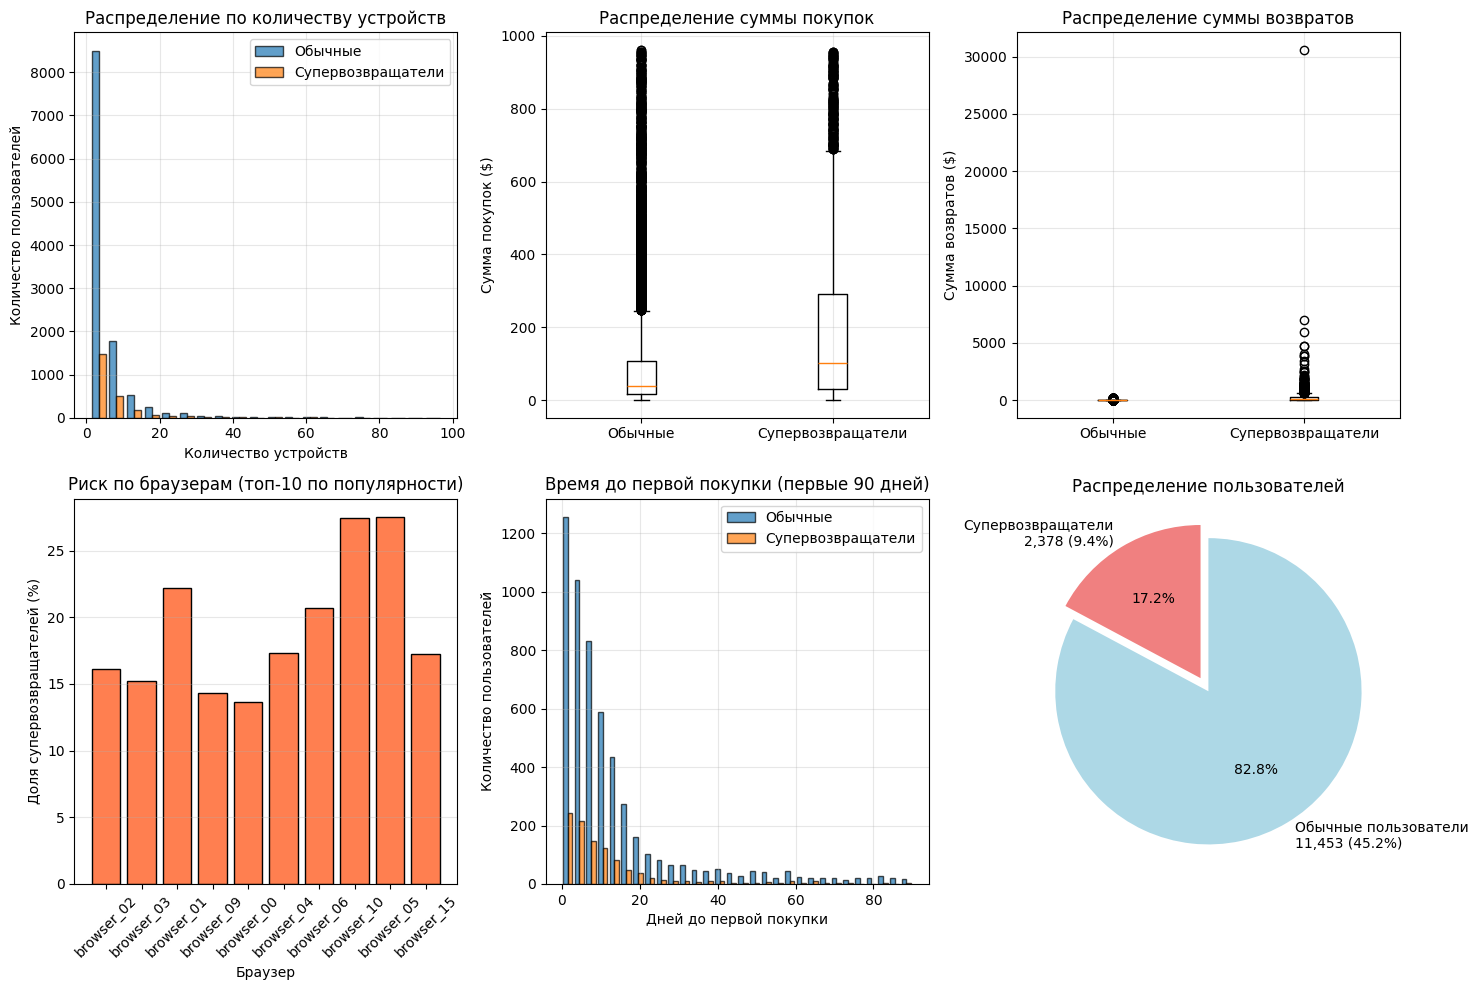



Итоговый портрет супервозвращателя:

📋 Ключевые характеристики:

1. Технический профиль:
• Использует в среднем 7.2 устройств (на 41% больше обычных)

2. Цифровые привычки:
• Чаще использует браузеры: browser_02, browser_01, browser_03
• Наибольший риск у браузера 'browser_05' (27.5% супервозвращателей)

3. Временные паттерны:
• Делает первую покупку в среднем через 15.5 дней (обычные: 16.2 дней)

4. Финансовое поведение:
• Совершает покупки на 2.0x больше
• Но возвращает в 66.6x больше


In [ ]:
# портрет пользователя с большими возвратами

# Несколько способов определить "супервозвращателей"
df_clean['return_ratio'] = df_clean['total_return'] / df_clean['total_buy'].replace(0, np.nan)

# Способ 1: По историческим возвратам (возвраты > 50% от покупок)
df_clean['high_historical_return'] = df_clean['return_ratio'] > 0.5

# Способ 2: По будущим возвратам (target в топ-10%)
return_threshold = df_clean['target'].quantile(0.9)  # 90-й перцентиль
df_clean['high_future_return'] = df_clean['target'] > return_threshold

# Способ 3: По абсолютным значениям возвратов (топ-5% по total_return)
return_amount_threshold = df_clean['total_return'].quantile(0.95)
df_clean['high_return_amount'] = df_clean['total_return'] > return_amount_threshold

# Комбинированный критерий: хотя бы один из признаков
df_clean['super_returner'] = df_clean['high_historical_return'] | df_clean['high_future_return'] | df_clean['high_return_amount']

# Статистика
super_returners = df_clean[df_clean['super_returner']]
normal_users = df_clean[~df_clean['super_returner']]

print(f"\nОбщая статистика:")
print(f"Всего пользователей: {len(df_clean):,}")
print(f"Супервозвращателей: {len(super_returners):,} ({len(super_returners)/len(df_clean)*100:.1f}%)")
print(f"Обычных пользователей: {len(normal_users):,} ({len(normal_users)/len(df_clean)*100:.1f}%)")

print(f"\nФинансовые показатели:")
print(f"Средние покупки супервозвращателей: ${super_returners['total_buy'].mean():.2f}")
print(f"Средние возвраты супервозвращателей: ${super_returners['total_return'].mean():.2f}")
if super_returners['total_buy'].sum() > 0:
    print(f"Коэффициент возвратов: {(super_returners['total_return'].sum()/super_returners['total_buy'].sum()*100):.1f}%")

print(f"\nСравнение с обычными пользователями:")
print(f"Отношение покупок: {super_returners['total_buy'].mean()/normal_users['total_buy'].mean():.2f}x")
print(f"Отношение возвратов: {super_returners['total_return'].mean()/normal_users['total_return'].mean():.2f}x")

# Количество устройств
print(f"\nКоличество устройств:")
print(f"Супервозвращатели:")
print(f"Среднее: {super_returners['platform_num'].mean():.1f}")
print(f"Медиана: {super_returners['platform_num'].median():.1f}")
print(f">6 устройств: {(super_returners['platform_num'] > 6).sum()/len(super_returners)*100:.1f}%")

print(f"\nОбычные пользователи:")
print(f"Среднее: {normal_users['platform_num'].mean():.1f}")
print(f"Медиана: {normal_users['platform_num'].median():.1f}")
print(f">6 устройств: {(normal_users['platform_num'] > 6).sum()/len(normal_users)*100:.1f}%")

# Браузеры
print(f"\nПредпочитаемые браузеры:")
top_browsers_super = super_returners['browser'].value_counts(normalize=True).head(5) * 100
top_browsers_normal = normal_users['browser'].value_counts(normalize=True).head(5) * 100

print(f"Топ-5 браузеров супервозвращателей:")
for browser, percent in top_browsers_super.items():
    print(f"• {browser}: {percent:.1f}%")

print(f"\nТоп-5 браузеров обычных пользователей:")
for browser, percent in top_browsers_normal.items():
    print(f"• {browser}: {percent:.1f}%")

# Браузеры с максимальным риском
browser_risk = df_clean.groupby('browser').agg({
    'user_id': 'count',
    'super_returner': 'mean'
})
browser_risk = browser_risk[browser_risk['user_id'] > 50]  # Минимум 50 пользователей
browser_risk = browser_risk.sort_values('super_returner', ascending=False)

print(f"\nБраузеры с наивысшим риском (доля супервозвращателей):")
print(browser_risk.head(5).round(3))

# Время до первой покупки
if 'days_to_first_buy' not in df_clean.columns:
    df_clean['days_to_first_buy'] = (df_clean['first_buy'] - df_clean['reg_dt']).dt.days

# Убираем аномалии
valid_super = super_returners['days_to_first_buy'].dropna()
valid_super = valid_super[(valid_super >= 0) & (valid_super <= 365)]
valid_normal = normal_users['days_to_first_buy'].dropna()
valid_normal = valid_normal[(valid_normal >= 0) & (valid_normal <= 365)]

print(f"\nВремя до первой покупки:")
print(f"Супервозвращатели:")
if len(valid_super) > 0:
    print(f"Среднее: {valid_super.mean():.1f} дней")
    print(f"Медиана: {valid_super.median():.1f} дней")
    print(f"Менее недели: {(valid_super <= 7).sum()/len(valid_super)*100:.1f}%")
else:
    print(f"Нет данных")

print(f"\nОбычные пользователи:")
if len(valid_normal) > 0:
    print(f"Среднее: {valid_normal.mean():.1f} дней")
    print(f"Медиана: {valid_normal.median():.1f} дней")
    print(f"Менее недели: {(valid_normal <= 7).sum()/len(valid_normal)*100:.1f}%")
else:
    print(f"Нет данных")

# Создаем сегменты по покупкам ДО анализа
df_clean['purchase_segment'] = pd.qcut(df_clean['total_buy'], q=4, labels=['Низкие', 'Ниже среднего', 'Выше среднего', 'Высокие'])

# Обновляем группы после создания сегмента
super_returners = df_clean[df_clean['super_returner']]
normal_users = df_clean[~df_clean['super_returner']]

print(f"\nПаттерны покупок:")
print(f"Супервозвращатели:")
print(f"Средний чек: ${super_returners['total_buy'].mean():.2f}")
print(f"Медианный чек: ${super_returners['total_buy'].median():.2f}")
print(f"Стандартное отклонение: ${super_returners['total_buy'].std():.2f}")

print(f"\nОбычные пользователи:")
print(f"Средний чек: ${normal_users['total_buy'].mean():.2f}")
print(f"Медианный чек: ${normal_users['total_buy'].median():.2f}")
print(f"Стандартное отклонение: ${normal_users['total_buy'].std():.2f}")

# Распределение по категориям покупок
print(f"\nРаспределение по суммам покупок:")
for segment in ['Низкие', 'Ниже среднего', 'Выше среднего', 'Высокие']:
    segment_super = super_returners[super_returners['purchase_segment'] == segment]
    segment_normal = normal_users[normal_users['purchase_segment'] == segment]

    if len(segment_super) > 0 and len(segment_normal) > 0:
        risk_ratio = len(segment_super) / len(segment_normal) if len(segment_normal) > 0 else 0
        print(f"  {segment}: {len(segment_super)} супервозвращателей, "
              f"риск в {risk_ratio:.1f} раза выше")

# Создаем флаги аномалий если их нет
if 'anomaly_login' not in df_clean.columns:
    df_clean['anomaly_login'] = df_clean['first_login'] < df_clean['reg_dt']
if 'anomaly_buy' not in df_clean.columns:
    df_clean['anomaly_buy'] = df_clean['first_buy'] < df_clean['reg_dt']

metrics_to_test = ['platform_num', 'total_buy', 'total_return', 'days_to_first_buy']

print("\nРезультаты Т-тестов:")
for metric in metrics_to_test:
    if metric in df_clean.columns:
        # Убираем пропуски
        super_data = super_returners[metric].dropna()
        normal_data = normal_users[metric].dropna()

        if len(super_data) > 1 and len(normal_data) > 1:
            from scipy import stats
            t_stat, p_value = stats.ttest_ind(super_data, normal_data, equal_var=False)

            print(f"\n{metric.upper()}:")
            print(f"• t-статистика: {t_stat:.3f}")
            print(f"• p-value: {p_value:.6f}")
            print(f"• Разница: {'СТАТИСТИЧЕСКИ ЗНАЧИМА' if p_value < 0.05 else 'НЕ значима'}")

# визуализация портрета супервозвращателя
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Распределение количества устройств
axes[0, 0].hist([normal_users['platform_num'], super_returners['platform_num']],
                bins=20, label=['Обычные', 'Супервозвращатели'], alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Количество устройств')
axes[0, 0].set_ylabel('Количество пользователей')
axes[0, 0].set_title('Распределение по количеству устройств')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Boxplot: Сумма покупок
box_data = [normal_users['total_buy'], super_returners['total_buy']]
axes[0, 1].boxplot(box_data, labels=['Обычные', 'Супервозвращатели'])
axes[0, 1].set_ylabel('Сумма покупок ($)')
axes[0, 1].set_title('Распределение суммы покупок')
axes[0, 1].grid(True, alpha=0.3)

# Boxplot: Сумма возвратов
box_data_returns = [normal_users['total_return'], super_returners['total_return']]
axes[0, 2].boxplot(box_data_returns, labels=['Обычные', 'Супервозвращатели'])
axes[0, 2].set_ylabel('Сумма возвратов ($)')
axes[0, 2].set_title('Распределение суммы возвратов')
axes[0, 2].grid(True, alpha=0.3)

# Доля супервозвращателей по браузерам (топ-10)
top_10_browsers = df_clean['browser'].value_counts().head(10).index
browser_risk_top = browser_risk.loc[top_10_browsers] if not browser_risk.empty else pd.DataFrame()

if not browser_risk_top.empty:
    axes[1, 0].bar(browser_risk_top.index, browser_risk_top['super_returner'] * 100,
                   color='coral', edgecolor='black')
    axes[1, 0].set_xlabel('Браузер')
    axes[1, 0].set_ylabel('Доля супервозвращателей (%)')
    axes[1, 0].set_title('Риск по браузерам (топ-10 по популярности)')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3, axis='y')
else:
    axes[1, 0].text(0.5, 0.5, 'Нет данных по браузерам',
                   ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_title('Риск по браузерам')

# Время до первой покупки (ограниченное 90 дней)
max_days = 90
super_days = super_returners['days_to_first_buy'].dropna()
super_days = super_days[(super_days >= 0) & (super_days <= max_days)]
normal_days = normal_users['days_to_first_buy'].dropna()
normal_days = normal_days[(normal_days >= 0) & (normal_days <= max_days)]

if len(super_days) > 0 and len(normal_days) > 0:
    axes[1, 1].hist([normal_days, super_days], bins=30,
                    label=['Обычные', 'Супервозвращатели'], alpha=0.7, edgecolor='black')
    axes[1, 1].set_xlabel('Дней до первой покупки')
    axes[1, 1].set_ylabel('Количество пользователей')
    axes[1, 1].set_title(f'Время до первой покупки (первые {max_days} дней)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'Нет данных по времени покупок',
                   ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Время до первой покупки')

# Круговая диаграмма: распределение пользователей
sizes = [len(super_returners), len(normal_users)]
labels = [f'Супервозвращатели\n{sizes[0]:,} ({sizes[0]/len(df)*100:.1f}%)',
          f'Обычные пользователи\n{sizes[1]:,} ({sizes[1]/len(df)*100:.1f}%)']
colors = ['lightcoral', 'lightblue']

axes[1, 2].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
               startangle=90, explode=(0.1, 0))
axes[1, 2].set_title('Распределение пользователей')

plt.tight_layout()
plt.show()

# итоговый портрет супервозвращателя
print('\n\nИтоговый портрет супервозвращателя:')
print(f"\nКлючевые характеристики:")
print(f"\n1. Технический профиль:")
print(f"• Использует в среднем {super_returners['platform_num'].mean():.1f} устройств "
      f"(на {((super_returners['platform_num'].mean()/normal_users['platform_num'].mean()-1)*100):.0f}% больше обычных)")

print(f"\n2. Цифровые привычки:")
if not top_browsers_super.empty:
    print(f"• Чаще использует браузеры: {', '.join(top_browsers_super.head(3).index.tolist())}")
if not browser_risk.empty:
    print(f"• Наибольший риск у браузера '{browser_risk.index[0]}' "
          f"({browser_risk.iloc[0]['super_returner']*100:.1f}% супервозвращателей)")

print(f"\n3. Временные паттерны:")
print(f"• Делает первую покупку в среднем через {valid_super.mean() if len(valid_super) > 0 else 'N/A':.1f} дней "
      f"(обычные: {valid_normal.mean() if len(valid_normal) > 0 else 'N/A':.1f} дней)")

print(f"\n4. Финансовое поведение:")
print(f"• Совершает покупки на {super_returners['total_buy'].mean()/normal_users['total_buy'].mean():.1f}x больше")
print(f"• Но возвращает в {super_returners['total_return'].mean()/normal_users['total_return'].mean():.1f}x больше")


# Гипотезы

In [110]:
# Укажите список + стратегию проверки
# По browser:
# Гипотеза: Клиенты с редко используемым браузером могут быть более склонны к поиску выгоды и возвратам. Пользователи с наиболее популярным браузером (по статистике в мире это Safari на Apple) могут иметь более высокий доход и быть менее чувствительными к цене, реже возвращать. 
# На что смотреть при проверке: Средний target и доля loss_makers по каждому браузеру. Статистически значимые отличия.

# По platform_num:
# Гипотеза: Пользователи заходившие с 1 устройства могут быть менее вовлеченными или более "случайными".
# На что смотреть при проверке: Распределение target по количеству устройств. Есть ли оптимальное значение?

# По времени жизни (user_lifetime, days_to_first_buy):
# Гипотеза 1: "Свежие" клиенты (неделя/месяц) чаще возвращают, так как пробуют сервис.
# Гипотеза 2: Клиенты, которые долго думали перед первой покупкой (days_to_first_buy большой), более осознанны и реже возвращают.
# На что смотреть при проверке: Зависимость target от user_lifetime (линейная? снижается после 3 месяцев?).

# Важный инсайт: Можно выявить "ловушку лояльности": клиенты с высоким total_buy (кажется, лояльные) могут иметь и высокий total_return. Они не лояльные, а просто активные, в том числе в возвратах.

# Гипотеза: Клиенты с 'красным флагом' (отрицательный таргет) имеют уникальные характеристики
# Описание: Анализируем клиентов с таргетом < 0 (возвраты превысили покупки в прогнозном периоде).
# Что проверяем: Отличаются ли эти клиенты по возрасту, количеству устройств или браузерам от остальных?
# Ожидание: Эти клиенты могут быть новыми или использовать определенные браузеры/устройства.

## ОБЪЯСНЕНИЕ СТАТИСТИЧЕСКИХ МЕТОДОВ
1. Shapiro-Wilk Test (shapiro):
   - Назначение: Проверка нормальности распределения
   - Почему выбран: Это один из самых мощных тестов для проверки нормальности
   - Интерпретация: H0 - данные нормально распределены, p < 0.05 отклоняем H0
   - Использование: Перед выбором параметрических/непараметрических тестов

2. Mann-Whitney U Test (mannwhitneyu):
   - Назначение: Сравнение двух независимых групп (непараметрический)
   - Почему выбран: Когда распределение не нормальное или данные ordinal
   - Альтернатива: t-test для нормальных распределений
   - Использование: Сравнение редких vs распространенных браузеров

3. Kruskal-Wallis H Test (kruskal):
   - Назначение: Сравнение 3+ независимых групп (непараметрический)
   - Почему выбран: Непараметрический аналог ANOVA
   - Альтернатива: One-way ANOVA для нормальных распределений
   - Использование: Сравнение нескольких групп по platform_num
   
4. Z-score (zscore):
   - Назначение: Стандартизация и выявление выбросов
   - Формула: z = (x - μ) / σ
   - Пороговое значение: |z| > 2 или 3 считается выбросом
   - Использование: Выявление аномальных пользователей в total_buy/total_return

5. Pearson Correlation (pearsonr):
   - Назначение: Измерение линейной связи между двумя переменными
   - Диапазон: от -1 (полная отрицательная) до +1 (полная положительная)
   - Использование: Анализ связи между total_buy и total_return

In [111]:
# Анализируем распределение platform_num
platform_counts = df['platform_num'].value_counts()
print("Распределение platform_num (первые 30):")
print(platform_counts.head(30))
print(f"\nВсего уникальных значений: {len(platform_counts)}")

Распределение platform_num (первые 30):
platform_num
1     6146
2     4903
3     3353
4     2254
5     1709
6     1251
7      940
8      675
9      592
10     445
11     349
12     278
13     236
14     208
15     185
17     149
16     139
19     112
20      90
18      89
22      82
23      63
21      62
24      60
26      54
27      52
25      51
28      50
29      35
30      30
Name: count, dtype: int64

Всего уникальных значений: 184


In [112]:
# Анализ браузеров
browser_counts = df['browser'].value_counts()
print(browser_counts.head(20))

# Группируем редкие браузеры в 'other'
threshold = 10  # если браузер встречается менее 10 раз -> other
common_browsers = browser_counts[browser_counts >= threshold].index.tolist()

def categorize_browser(browser):
    if browser in common_browsers:
        return browser
    else:
        return 'other'

df['browser_category'] = df['browser'].apply(categorize_browser)
print(df['browser_category'].value_counts())

browser
browser_02    9500
browser_03    5789
browser_01    4101
browser_09    1563
browser_00    1096
browser_04     624
browser_06     562
browser_10     382
browser_05     366
browser_15     323
browser_11     240
browser_17     140
browser_19     130
browser_08     129
browser_18      83
browser_16      68
browser_22      65
browser_13      47
browser_07      46
browser_20      31
Name: count, dtype: int64
browser_category
browser_02    9500
browser_03    5789
browser_01    4101
browser_09    1563
browser_00    1096
browser_04     624
browser_06     562
browser_10     382
browser_05     366
browser_15     323
browser_11     240
browser_17     140
browser_19     130
browser_08     129
browser_18      83
browser_16      68
browser_22      65
browser_13      47
browser_07      46
browser_20      31
other           30
browser_12      20
Name: count, dtype: int64


In [113]:
# Функция для категоризации platform_num
def categorize_platform(num):
    if pd.isna(num):
        return 'unknown'
    elif num == 1:
        return '1'
    elif 2 <= num <= 3:
        return '2-3'
    elif 4 <= num <= 10:
        return '4-10'
    elif 11 <= num <= 50:
        return '11-50'
    else:
        return '51+'

# Применяем категоризацию
df['platform_num_category'] = df['platform_num'].apply(categorize_platform)

# Проверяем распределение
print(df['platform_num_category'].value_counts())

platform_num_category
2-3      8256
4-10     7866
1        6146
11-50    2724
51+       343
Name: count, dtype: int64


In [114]:
# Анализ total_buy
percentiles = [0, 0.25, 0.5, 0.75, 0.95, 1.0]
print(df['total_buy'].describe())
print("Перцентили:", df['total_buy'].quantile(percentiles))

# Разбиваем на группы по квантилям
bins = [0, 20, 100, 1000, 5000, float('inf')]
labels = ['0-20', '21-100', '101-1000', '1001-5000', '5000+']

df['total_buy_category'] = pd.cut(df['total_buy'], bins=bins, labels=labels, right=False)
print(df['total_buy_category'].value_counts())

count     25335.000000
mean        898.549417
std        6815.549317
min           0.000000
25%          19.359396
50%          52.715792
75%         203.526684
max      490447.985326
Name: total_buy, dtype: float64
Перцентили: 0.00         0.000000
0.25        19.359396
0.50        52.715792
0.75       203.526684
0.95      2731.102603
1.00    490447.985326
Name: total_buy, dtype: float64
total_buy_category
21-100       9618
101-1000     6639
0-20         6544
1001-5000    1725
5000+         809
Name: count, dtype: int64


In [115]:
# Сохраняем очищенный файл с новыми категориями
df.to_csv('marketplace_cleaned_categorized.csv', index=False)
print("Файл успешно сохранён: marketplace_cleaned_categorized.csv")

Файл успешно сохранён: marketplace_cleaned_categorized.csv


In [28]:
# Загрузка и подготовка данных из ОЧИЩЕННОГО файла
df = pd.read_csv('marketplace_cleaned_categorized.csv')

# Преобразование дат (если они есть в очищенном файле)
date_columns = ['first_login', 'reg_dt', 'first_buy']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Создаем дополнительные переменные (если нужные колонки существуют)
if 'reg_dt' in df.columns and 'first_buy' in df.columns:
    df['days_to_first_buy'] = (df['first_buy'] - df['reg_dt']).dt.days

if 'first_login' in df.columns:
    df['user_lifetime'] = (pd.Timestamp('2025-12-14') - df['first_login']).dt.days

if 'target' in df.columns:
    df['is_loss_maker'] = df['target'] < 0
    df['is_profitable'] = df['target'] > 0

if 'total_buy' in df.columns and 'total_return' in df.columns:
    df['buy_return_ratio'] = df['total_return'] / df['total_buy'].replace(0, np.nan)

# Проверка гипотез

## Категоризация

In [29]:
# функции для анализа групп с Z-score внутри каждой категории и проверки статистической значимости между категориями
def analyze_groups_with_zscore(df: pd.DataFrame, 
                               group_column: str, 
                               target_column: str,
                               group_names: List[str] = ['Низкий', 'Средний', 'Высокий'],
                               zscore_thresholds: List[float] = [-1, 1]) -> Dict[str, Any]:
    """
    Анализирует группы с Z-score внутри каждой категории
    
    Parameters:
    -----------
    df : pd.DataFrame
        Исходный DataFrame
    group_column : str
        Колонка с категориями (например, 'platform_num_category')
    target_column : str
        Целевая переменная для анализа (например, 'total_buy', 'target')
    group_names : List[str]
        Названия Z-score групп внутри каждой категории
    zscore_thresholds : List[float]
        Пороги для Z-score групп
    
    Returns:
    --------
    Dict[str, Any]
        Результаты анализа
    """

    print(f"\Анализ z-score внутри категорий")
    print(f"Группа: {group_column}, Целевая переменная: {target_column}")
    
    # Проверяем наличие колонок
    if group_column not in df.columns:
        print(f"Колонка '{group_column}' не найдена!")
        return {}
    
    if target_column not in df.columns:
        print(f"Целевая переменная '{target_column}' не найдена!")
        return {}
    
    # Получаем уникальные категории
    categories = df[group_column].dropna().unique()
    print(f"\nНайдено категорий: {len(categories)}")
    
    results = {
        'group_column': group_column,
        'target_column': target_column,
        'categories': {},
        'overall_stats': {},
        'zscore_groups': pd.DataFrame()
    }
    
    # Подготовим DataFrame для хранения Z-score групп
    zscore_data = []
    
    for category in categories:
        # Фильтруем данные по категории
        category_data = df[df[group_column] == category].copy()
        
        if len(category_data) < 3:  # Минимум 3 наблюдения для Z-score
            print(f"Категория '{category}': недостаточно данных (n={len(category_data)})")
            continue
        
        # Рассчитываем Z-score внутри категории
        target_values = category_data[target_column].fillna(category_data[target_column].median())
        
        # Проверяем, что данные не константные
        if target_values.std() == 0:
            print(f"Категория '{category}': данные константные, Z-score не имеет смысла")
            z_scores = pd.Series(0, index=target_values.index)
        else:
            z_scores = zscore(target_values, nan_policy='omit')
            z_scores = pd.Series(z_scores, index=target_values.index)
        
        # Создаем Z-score группы
        zscore_groups = pd.cut(
            z_scores, 
            bins=[-np.inf, zscore_thresholds[0], zscore_thresholds[1], np.inf], 
            labels=group_names,
            include_lowest=True
        )
        
        # Добавляем в исходные данные
        category_data[f'{target_column}_zscore'] = z_scores
        category_data[f'{target_column}_zgroup'] = zscore_groups
        
        # Собираем статистику
        category_stats = {
            'n': len(category_data),
            'mean': target_values.mean(),
            'median': target_values.median(),
            'std': target_values.std(),
            'min': target_values.min(),
            'max': target_values.max(),
            'q1': target_values.quantile(0.25),
            'q3': target_values.quantile(0.75),
            'zscore_low': (zscore_groups == group_names[0]).sum(),
            'zscore_medium': (zscore_groups == group_names[1]).sum(),
            'zscore_high': (zscore_groups == group_names[2]).sum(),
            'data': category_data
        }
        
        results['categories'][category] = category_stats
        
        # Сохраняем для общего анализа
        for idx, row in category_data.iterrows():
            zscore_data.append({
                'index': idx,
                'category': category,
                f'{target_column}': row[target_column],
                f'{target_column}_zscore': row[f'{target_column}_zscore'],
                f'{target_column}_zgroup': row[f'{target_column}_zgroup'],
                'combined_group': f"{category}_{row[f'{target_column}_zgroup']}"
            })
        
        print(f"\nКатегория '{category}' (n={len(category_data)}):")
        print(f"Среднее: {target_values.mean():.2f} ± {target_values.std():.2f}")
        print(f"Z-score группы: {group_names[0]}:{category_stats['zscore_low']}, "
              f"{group_names[1]}:{category_stats['zscore_medium']}, "
              f"{group_names[2]}:{category_stats['zscore_high']}")
    
    # Создаем общий DataFrame с Z-score группами
    if zscore_data:
        results['zscore_groups'] = pd.DataFrame(zscore_data).set_index('index')
        
        # Общая статистика
        print("\n Общая статистика по z-score группам:")
        
        # Анализ распределения по комбинированным группам
        combined_groups = results['zscore_groups']['combined_group'].value_counts()
        print("\nРаспределение по комбинированным группам (категория_Z-группа):")
        for group, count in combined_groups.head(10).items():
            print(f"   {group}: {count} наблюдений")
        
        if len(combined_groups) > 10:
            print(f"   ... и еще {len(combined_groups) - 10} групп")
        
        # Сводная таблица
        print("\nСводная таблица по категориям:")
        summary_df = pd.DataFrame.from_dict(results['categories'], orient='index')
        print(summary_df[['n', 'mean', 'median', 'std', 
                         'zscore_low', 'zscore_medium', 'zscore_high']].round(2))
    
    return results


def analyze_categorical_groups_statistically(df: pd.DataFrame, 
                                            groups_dict: Dict[str, List], 
                                            target_var: str = 'target', 
                                            alpha: float = 0.05) -> Tuple[Optional[pd.DataFrame], str, float]:
    """
    Анализирует статистическую значимость различий между КАТЕГОРИАЛЬНЫМИ группами
    
    Parameters:
    -----------
    df : pd.DataFrame
        Исходный DataFrame
    groups_dict : Dict[str, List]
        Словарь с индексами для каждой КАТЕГОРИАЛЬНОЙ группы
    target_var : str
        Целевая переменная для анализа
    alpha : float
        Уровень значимости
    
    Returns:
    --------
    Tuple[Optional[pd.DataFrame], str, float]
        Статистика по группам, тип теста, p-value
    """
    print(f"Статистический анализ категориальных групп\n")
    print(f"Целевая переменная: '{target_var}'")
    
    # Собираем данные по группам
    group_data = []
    group_stats = []
    valid_groups = []
    
    for group_name, group_indices in groups_dict.items():
        if not group_indices:  # Проверяем, что группа не пустая
            print(f"Группа '{group_name}' пустая")
            continue
            
        # Берем только существующие индексы
        valid_indices = [idx for idx in group_indices if idx in df.index]
        if not valid_indices:
            print(f"В группе '{group_name}' нет валидных индексов")
            continue
            
        group_values = df.loc[valid_indices, target_var].dropna()
        
        if len(group_values) < 2:  # Минимум 2 наблюдения
            print(f"В группе '{group_name}' недостаточно данных (n={len(group_values)})")
            continue
        
        group_data.append(group_values)
        valid_groups.append(group_name)
        
        # Статистика группы
        stats_dict = {
            'Группа': group_name,
            'N': len(group_values),
            'Среднее': group_values.mean(),
            'Медиана': group_values.median(),
            'Std': group_values.std(),
            'Min': group_values.min(),
            'Max': group_values.max(),
            'Q1': group_values.quantile(0.25),
            'Q3': group_values.quantile(0.75),
            'IQR': group_values.quantile(0.75) - group_values.quantile(0.25),
            'Коэф. вариации': (group_values.std() / group_values.mean() * 100 
                              if group_values.mean() != 0 else np.nan)
        }
        group_stats.append(stats_dict)
    
    # Проверяем, что есть хотя бы 2 группы с данными
    if len(group_data) < 2:
        print(f"Недостаточно групп с данными для сравнения (нужно минимум 2, а есть {len(group_data)})")
        return None, "insufficient_data", 1.0
    
    # Выводим статистику
    stats_df = pd.DataFrame(group_stats)
    print("\nОсновная статистика по категориальным группам:")
    print(stats_df.round(4).to_string(index=False))
    
    # Проверка нормальности
    print("\nПроверка нормальности распределений:")
    normality_results = []
    normality_details = []
    
    for i, group_vals in enumerate(group_data):
        group_name = valid_groups[i]
        
        if len(group_vals) < 3:
            print(f"В группе '{group_name}': недостаточно данных (n={len(group_vals)} < 3)")
            normality_results.append(False)
            normality_details.append({
                'group': group_name,
                'n': len(group_vals),
                'test': 'N/A',
                'p_value': np.nan,
                'is_normal': False
            })
            continue
        
        # Выбор теста нормальности в зависимости от размера выборки
        if len(group_vals) <= 5000:  # Shapiro-Wilk для небольших выборок
            stat, p = shapiro(group_vals)
            test_name = "Shapiro-Wilk"
        else:  # D'Agostino для больших выборок
            stat, p = normaltest(group_vals)
            test_name = "D'Agostino's K²"
        
        is_normal = p > alpha
        normality_results.append(is_normal)
        normality_details.append({
            'group': group_name,
            'n': len(group_vals),
            'test': test_name,
            'p_value': p,
            'is_normal': is_normal
        })
        
        status = "нормальное" if is_normal else "не нормальное"
        print(f"Группа '{group_name}' (n={len(group_vals)}): {test_name}, p={p:.4f} ({status})")
    
    # Выбор и проведение статистического теста
    print("\nВыбор и проведение статистического теста")
    
    # Решаем, какой тест использовать
    use_parametric = all(normality_results)
    
    if use_parametric and len(group_data) >= 2:
        print("Все группы имеют нормальное распределение, применяем ANOVA")
        try:
            f_stat, p_val = f_oneway(*group_data)
            test_type = "ANOVA"
            test_stat = f_stat
        except Exception as e:
            print(f"Ошибка при выполнении ANOVA: {e}")
            print("Применяем непараметрический тест Kruskal-Wallis")
            h_stat, p_val = kruskal(*group_data)
            test_type = "Kruskal-Wallis (fallback)"
            test_stat = h_stat
    else:
        print("Не все группы имеют нормальное распределение, применяем Kruskal-Wallis")
        h_stat, p_val = kruskal(*group_data)
        test_type = "Kruskal-Wallis"
        test_stat = h_stat
    
    # Вывод результатов теста
    print(f"\nРезультаты теста ({test_type}):")
    print(f"Статистика теста: {test_stat:.4f}")
    print(f"p-value: {p_val:.6f}")
    print(f"Уровень значимости (alpha): {alpha}")
    
    # Интерпретация p-value
    significance_levels = [
        (0.001, "*** выосоко значимо", "***"),
        (0.01, "** значимо", "**"),
        (alpha, "* слабо значимо", "*"),
        (1.0, "не значимо", "")
    ]
    
    significance = ""
    stars = ""
    for level, text, symbol in significance_levels:
        if p_val < level:
            significance = text
            stars = symbol
            break
    
    print(f"Результат: {significance} {stars}")
    print(f"Вывод: {'есть' if p_val < alpha else 'отсутствуют'} статистически значимые различия между группами")
    
    # Дополнительная информация
    if p_val < alpha:
        print(f"\nПоскольку p-value < {alpha}, можем выполнить post-hoc анализ:")
        print("1. Для ANOVA: Tukey's HSD или Dunnett's test")
        print("2. Для Kruskal-Wallis: Dunn's test с коррекцией Бонферрони")
    
    return stats_df, test_type, p_val


def create_groups_dict_from_category(df: pd.DataFrame, category_column: str) -> Dict[str, List]:
    """
    Создает словарь групп из категориальной колонки
    
    Parameters:
    -----------
    df : pd.DataFrame
        Исходный DataFrame
    category_column : str
        Колонка с категориями
    
    Returns:
    --------
    Dict[str, List]
        Словарь {название_группы: [индексы]}
    """
    if category_column not in df.columns:
        print(f"Колонка '{category_column}' не найдена!")
        return {}
    
    groups_dict = {}
    for category in df[category_column].dropna().unique():
        indices = df[df[category_column] == category].index.tolist()
        groups_dict[category] = indices
        print(f"Группа '{category}': {len(indices)} наблюдений")
    
    return groups_dict


def compare_categories_with_zscore_analysis(df: pd.DataFrame, 
                                           category_columns: List[str], 
                                           target_columns: List[str],
                                           zscore_thresholds: List[float] = [-1, 1]) -> Dict[str, Any]:
    """
    Полный анализ категорий с Z-score внутри каждой
    
    Parameters:
    -----------
    df : pd.DataFrame
        Исходный DataFrame
    category_columns : List[str]
        Список категориальных колонок для анализа
    target_columns : List[str]
        Список целевых переменных для анализа
    zscore_thresholds : List[float]
        Пороги для Z-score
    
    Returns:
    --------
    Dict[str, Any]
        Результаты всех анализов
    """

    print("Полный анализ категорий z-score")

    
    all_results = {}
    
    for category_col in category_columns:
        if category_col not in df.columns:
            print(f"\nКолонка '{category_col}' не найдена, пропускаем")
            continue
            
        print(f"Анализ категории: {category_col}")
        
        category_results = {}
        
        # 1. Создаем группы из категории
        print("\n1. Создание групп из категории:")
        groups_dict = create_groups_dict_from_category(df, category_col)
        
        if not groups_dict:
            print("Не удалось создать группы")
            continue
        
        # 2. Анализ для каждой целевой переменной
        for target_col in target_columns:
            if target_col not in df.columns:
                print(f"\nЦелевая переменная '{target_col}' не найдена")
                continue
                
            print(f"\n2. Анализ целевой переменной: {target_col}")
            print(f"   {'-'*40}")
            
            # Статистический анализ между категориями
            stats_df, test_type, p_val = analyze_categorical_groups_statistically(
                df, groups_dict, target_col
            )
            
            # Z-score анализ внутри категорий
            zscore_results = analyze_groups_with_zscore(
                df, category_col, target_col, zscore_thresholds=zscore_thresholds
            )
            
            category_results[target_col] = {
                'stats': stats_df,
                'test_type': test_type,
                'p_value': p_val,
                'zscore_analysis': zscore_results
            }
        
        all_results[category_col] = category_results
    
    return all_results

## Гипотеза 1. Анализ по браузерам с Z-score разделением по популярности  
Клиенты, использующие редко встречающиеся браузеры, более склонны к возвратам (имеют более низкий target),
в то время как пользователи популярных браузеров демонстрируют более устойчивое поведение.

### Проверка

In [30]:
if 'browser_category' in df.columns:
    print(f"\nИспользуем категоризированную колонку: 'browser_category'")
    
    # Создаем словарь групп из категории браузеров
    print("\nСоздание групп из категории браузеров:")
    browser_groups_dict = create_groups_dict_from_category(df, 'browser_category')
    
    if browser_groups_dict:
        print(f"\nВсего групп: {len(browser_groups_dict)}")
        for group_name, indices in browser_groups_dict.items():
            group_targets = df.loc[indices, 'target'].dropna()
            avg_target = group_targets.mean() if len(group_targets) > 0 else 0
            return_rate = f"↑ возвраты" if avg_target < 0 else f"↓ возвраты" if avg_target > 0 else "~ баланс"
            print(f"• {group_name}: {len(indices)} пользователей, средний target: {avg_target:.4f} ({return_rate})")
    
        print("\nАнализ гипотезы 1:")

        # Статистический анализ между группами браузеров
        print("\nСтатистический анализ между группами браузеров:")
        stats_df, test_type, p_val = analyze_categorical_groups_statistically(
            df=df,
            groups_dict=browser_groups_dict,
            target_var='target',
            alpha=0.05
        )
        
        # Z-score анализ внутри каждой категории браузеров
        print("\nZ-score анализ внутри каждой категории браузеров:")
        browser_zscore_results = analyze_groups_with_zscore(
            df=df,
            group_column='browser_category',
            target_column='target',
            group_names=['Высокие возвраты', 'Средние возвраты', 'Низкие возвраты'],
            zscore_thresholds=[-0.5, 0.5]
        )
        
        # Детальный анализ для ключевых групп
        print("\nДетальный анализ для ключевых групп:")
        
        # Анализируем браузеры из 'other' категории
        if 'other' in browser_groups_dict:
            other_indices = browser_groups_dict['other']
            other_targets = df.loc[other_indices, 'target'].dropna()
            
            if len(other_targets) > 0:
                print(f"\nАнализ 'other' браузеров (n={len(other_targets)}):")
                print(f"• Средний target: {other_targets.mean():.4f}")
                print(f"• Медиана target: {other_targets.median():.4f}")
                print(f"• % пользователей с возвратами > покупок (target < 0): {(other_targets < 0).sum()/len(other_targets)*100:.1f}%")
                print(f"• % пользователей с балансом (target = 0): {(other_targets == 0).sum()/len(other_targets)*100:.1f}%")
                
                # Анализ экстремальных значений возвратов
                extreme_return_threshold = -0.5  # Сильные возвраты
                extreme_users = other_targets[other_targets < extreme_return_threshold]
                if len(extreme_users) > 0:
                    print(f"• Пользователи с сильными возвратами (target < {extreme_return_threshold}): {len(extreme_users)} ({len(extreme_users)/len(other_targets)*100:.1f}%)")
                
                # Сравниваем с популярными браузерами
                popular_browsers = [b for b in browser_groups_dict.keys() 
                                   if b != 'other' and len(browser_groups_dict[b]) > 50]
                
                if popular_browsers:
                    for browser in popular_browsers[:3]:  # Первые 3 популярных
                        browser_indices = browser_groups_dict[browser]
                        browser_targets = df.loc[browser_indices, 'target'].dropna()
                        
                        if len(browser_targets) > 0:
                            # T-test для сравнения
                            from scipy.stats import ttest_ind
                            t_stat, t_pval = ttest_ind(other_targets, browser_targets, equal_var=False)
                            
                            print(f"\nСравнение с '{browser}' (n={len(browser_targets)}):")
                            print(f"• Средний target '{browser}': {browser_targets.mean():.4f}")
                            print(f"• % с возвратами > покупок: {(browser_targets < 0).sum()/len(browser_targets)*100:.1f}%")
                            print(f"• T-test: t={t_stat:.3f}, p={t_pval:.4f}")
                            print(f"• {'есть' if t_pval < 0.05 else 'отсутствуют'} значимые различия в уровне возвратов")



Используем категоризированную колонку: 'browser_category'

Создание групп из категории браузеров:
Группа 'browser_00': 1096 наблюдений
Группа 'browser_01': 4101 наблюдений
Группа 'browser_02': 9500 наблюдений
Группа 'browser_03': 5789 наблюдений
Группа 'browser_04': 624 наблюдений
Группа 'browser_05': 366 наблюдений
Группа 'browser_06': 562 наблюдений
Группа 'browser_07': 46 наблюдений
Группа 'browser_08': 129 наблюдений
Группа 'browser_09': 1563 наблюдений
Группа 'browser_10': 382 наблюдений
Группа 'browser_11': 240 наблюдений
Группа 'browser_12': 20 наблюдений
Группа 'browser_13': 47 наблюдений
Группа 'other': 30 наблюдений
Группа 'browser_15': 323 наблюдений
Группа 'browser_16': 68 наблюдений
Группа 'browser_17': 140 наблюдений
Группа 'browser_18': 83 наблюдений
Группа 'browser_19': 130 наблюдений
Группа 'browser_20': 31 наблюдений
Группа 'browser_22': 65 наблюдений

Всего групп: 22
• browser_00: 1096 пользователей, средний target: 0.0143 (↓ возвраты)
• browser_01: 4101 пользовател

### Визуализация


ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ:


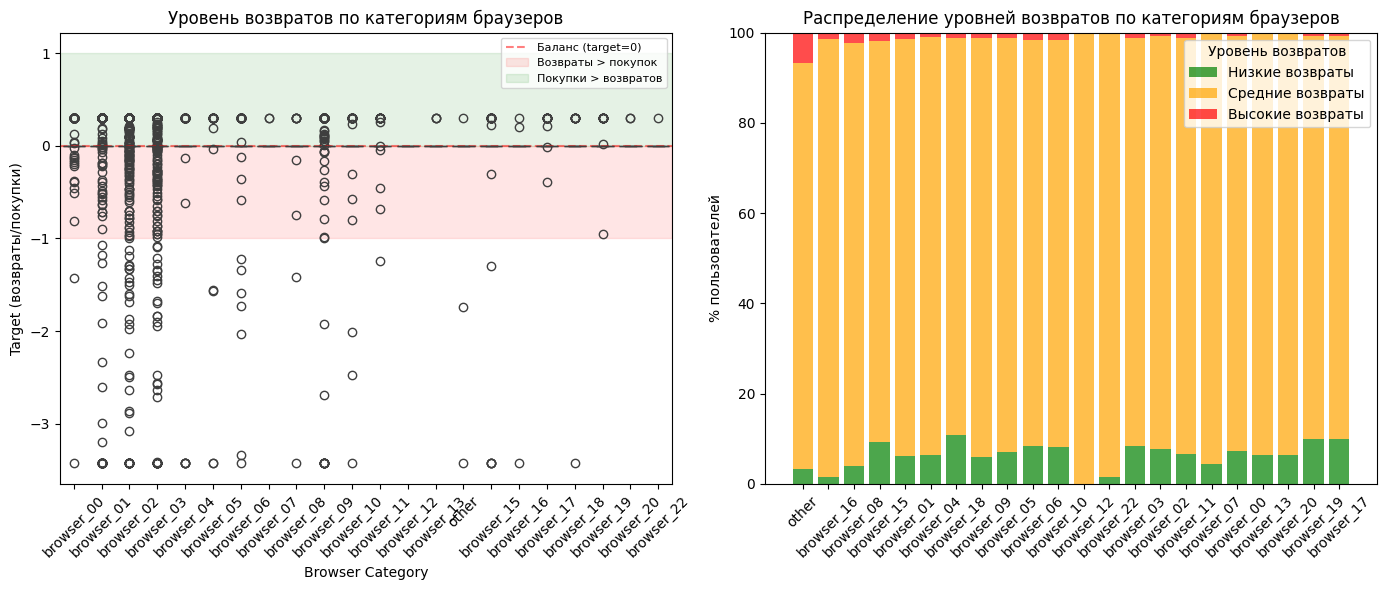


Дополнительный анализ 'other' категории:


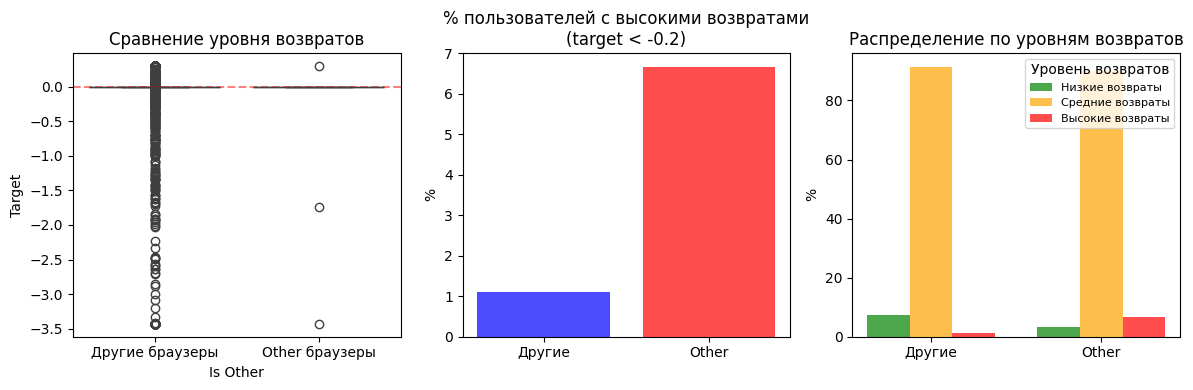

In [31]:
# Код визуализации гипотезы 1
# Визуализация результатов
print("\nВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ:")

# Подготовка данных для визуализации
viz_data = []
for group_name, indices in browser_groups_dict.items():
    group_targets = df.loc[indices, 'target'].dropna()
    if len(group_targets) > 0:
        for target in group_targets:
            viz_data.append({
                'Browser Category': group_name,
                'Target': target,
                'Return Level': 'Высокие возвраты' if target < -0.2 else 
                              'Средние возвраты' if target < 0.2 else 
                              'Низкие возвраты'
            })

if viz_data:
    viz_df = pd.DataFrame(viz_data)
    
    # Фильтруем группы с малым количеством данных для лучшей визуализации
    min_group_size = 10
    group_counts = viz_df['Browser Category'].value_counts()
    valid_groups = group_counts[group_counts >= min_group_size].index.tolist()
    filtered_df = viz_df[viz_df['Browser Category'].isin(valid_groups)]
    
    if len(filtered_df) > 0:
        # Boxplot с интерпретацией возвратов
        plt.figure(figsize=(14, 6))
        
        plt.subplot(1, 2, 1)
        sns.boxplot(x='Browser Category', y='Target', data=filtered_df)
        plt.title('Уровень возвратов по категориям браузеров')
        plt.xticks(rotation=45)
        plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Баланс (target=0)')
        plt.axhspan(-1, 0, alpha=0.1, color='red', label='Возвраты > покупок')
        plt.axhspan(0, 1, alpha=0.1, color='green', label='Покупки > возвратов')
        plt.ylabel('Target (возвраты/покупки)')
        plt.legend(loc='upper right', fontsize=8)
        
        # Bar plot средних значений с разделением по уровню возвратов
        plt.subplot(1, 2, 2)
        
        # Группируем по категориям и уровню возвратов
        pivot_data = filtered_df.groupby(['Browser Category', 'Return Level']).size().unstack(fill_value=0)
        pivot_data_pct = pivot_data.div(pivot_data.sum(axis=1), axis=0) * 100
        
        # Сортируем по среднему target
        group_means = filtered_df.groupby('Browser Category')['Target'].mean()
        sorted_categories = group_means.sort_values().index
        pivot_data_pct = pivot_data_pct.loc[sorted_categories]
        
        colors = {'Высокие возвраты': 'red', 'Средние возвраты': 'orange', 'Низкие возвраты': 'green'}
        bottom = np.zeros(len(pivot_data_pct))
        
        for level in ['Низкие возвраты', 'Средние возвраты', 'Высокие возвраты']:
            if level in pivot_data_pct.columns:
                plt.bar(range(len(pivot_data_pct)), pivot_data_pct[level], 
                       bottom=bottom, label=level, color=colors.get(level, 'gray'), alpha=0.7)
                bottom += pivot_data_pct[level]
        
        plt.xticks(range(len(pivot_data_pct)), pivot_data_pct.index, rotation=45)
        plt.title('Распределение уровней возвратов по категориям браузеров')
        plt.ylabel('% пользователей')
        plt.legend(title='Уровень возвратов')
        
        plt.tight_layout()
        plt.show()
        
        # Дополнительная визуализация для "other" vs остальные
        if 'other' in filtered_df['Browser Category'].unique():
            print(f"\nДополнительный анализ 'other' категории:")
            
            # Создаем бинарную переменную
            other_df = filtered_df.copy()
            other_df['Is Other'] = other_df['Browser Category'] == 'other'
            
            plt.figure(figsize=(12, 4))
            
            # Сравнение распределений
            plt.subplot(1, 3, 1)
            sns.boxplot(x='Is Other', y='Target', data=other_df)
            plt.title('Сравнение уровня возвратов')
            plt.xticks([0, 1], ['Другие браузеры', 'Other браузеры'])
            plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
            plt.ylabel('Target')
            
            # Процент пользователей с высокими возвратами
            plt.subplot(1, 3, 2)
            high_returns_pct = other_df.groupby('Is Other').apply(
                lambda x: (x['Target'] < -0.2).sum() / len(x) * 100
            )
            plt.bar(['Другие', 'Other'], high_returns_pct.values, alpha=0.7, color=['blue', 'red'])
            plt.title('% пользователей с высокими возвратами\n(target < -0.2)')
            plt.ylabel('%')
            
            # Распределение по уровням возвратов
            plt.subplot(1, 3, 3)
            return_dist = other_df.groupby(['Is Other', 'Return Level']).size().unstack()
            return_dist_pct = return_dist.div(return_dist.sum(axis=1), axis=0) * 100
            
            x = np.arange(2)
            width = 0.25
            for i, level in enumerate(['Низкие возвраты', 'Средние возвраты', 'Высокие возвраты']):
                if level in return_dist_pct.columns:
                    plt.bar(x + i*width - width, return_dist_pct[level].values, 
                           width, label=level, color=colors.get(level, 'gray'), alpha=0.7)
            
            plt.xticks(x, ['Другие', 'Other'])
            plt.title('Распределение по уровням возвратов')
            plt.ylabel('%')
            plt.legend(title='Уровень возвратов', fontsize=8)
            
            plt.tight_layout()
            plt.show()

## Вывод

ПРОБЛЕМНАЯ КАТЕГОРИЯ (наибольшие возвраты): 'other' (непопулярные браузеры)
   • Средний target: -0.1621
   • Интерпретация: Умеренные возвраты
   • Количество пользователей: 30

ЛУЧШАЯ КАТЕГОРИЯ (наименьшие возвраты): 'browser_17'
   • Средний target: 0.0265
   • Интерпретация: Низкие возвраты
   • Количество пользователей: 140

ГИПОТЕЗА H₂ (ПОДТВЕРЖДЕНА):
   Пользователи непопулярных браузеров имеют более высокие возвраты

СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ:
   • Тест: Kruskal-Wallis
   • p-value: 0.002911
   • Результат: ЕСТЬ статистически значимых различия в уровне возвратов

РЕКОМЕНДАЦИИ ПО УПРАВЛЕНИЮ ВОЗВРАТАМИ:
   1. Есть статистически значимые различия между браузерами
   2. Сфокусироваться на проблемных категориях браузеров
   3. Исследовать причины высоких возвратов в браузерах
   4. Перенять лучшие практики из браузера: browser_17
   5. Особое внимание к редким браузерам - возможны мошеннические схемы

## Гипотеза 2. Анализ по категоризированным platform_num (количество устройств)
Пользователи, заходившие только с одного устройства, могут быть менее вовлечёнными или более случайными клиентами.

### Проверка

In [ ]:
print("target = возвраты к покупкам в следующем месяце")
print("H₀: Уровень возвратов не зависит от количества устройств")
print("H₁: Есть оптимальное количество устройств с наименьшими возвратами")

# Проверяем, что колонка существует
if 'platform_num_category' in df.columns:
    print(f"\nИспользуем категоризированную колонку: 'platform_num_category'")
    
    # Создаем словарь групп из категории platform_num
    print("\nСоздание групп из категории platform_num:")
    platform_groups_dict = create_groups_dict_from_category(df, 'platform_num_category')
    
    if platform_groups_dict:
        print(f"\nВсего групп: {len(platform_groups_dict)}")
        for group_name, indices in platform_groups_dict.items():
            group_targets = df.loc[indices, 'target'].dropna()
            avg_target = group_targets.mean() if len(group_targets) > 0 else 0
            return_rate = f"↑ возвраты" if avg_target < 0 else f"↓ возвраты" if avg_target > 0 else "~ баланс"
            print(f"   • {group_name}: {len(indices)} пользователей, средний target: {avg_target:.4f} ({return_rate})")
        
        print("Анализ гипотезы 2:")
        
        # Статистический анализ между группами platform_num
        print("\nСтатистический анализ между группами platform_num:")
        stats_df, test_type, p_val = analyze_categorical_groups_statistically(
            df=df,
            groups_dict=platform_groups_dict,
            target_var='target',
            alpha=0.05
        )
        
        # Z-score анализ внутри каждой категории platform_num
        print("\nZ-score анализ внутри каждой категории platform_num:")
        platform_zscore_results = analyze_groups_with_zscore(
            df=df,
            group_column='platform_num_category',
            target_column='target',
            group_names=['Высокие возвраты', 'Средние возвраты', 'Низкие возвраты'],
            zscore_thresholds=[-0.5, 0.5]
        )
        
        # Анализ тренда (чем больше устройств, тем лучше/хуже)
        print("\nАнализ тренда по количеству устройств:")
        
        # Создаем упорядоченный список категорий по количеству устройств
        category_order = ['1', '2-3', '4-10', '11-50', '51+']
        valid_categories = [cat for cat in category_order if cat in platform_groups_dict]
        
        if len(valid_categories) >= 3:  # Минимум 3 категории для анализа тренда
            trend_data = []
            for category in valid_categories:
                indices = platform_groups_dict[category]
                targets = df.loc[indices, 'target'].dropna()
                if len(targets) > 0:
                    trend_data.append({
                        'category': category,
                        'category_order': valid_categories.index(category),
                        'mean_target': targets.mean(),
                        'median_target': targets.median(),
                        'n': len(targets)
                    })
            
            trend_df = pd.DataFrame(trend_data)
            
            # Проверяем корреляцию
            print(f"\nКорреляция между количеством устройств и уровнем возвратов:")
            
            # Параметрическая корреляция (Пирсон)
            pearson_corr, pearson_p = pearsonr(trend_df['category_order'], trend_df['mean_target'])
            print(f"• Пирсон: r={pearson_corr:.3f}, p={pearson_p:.4f}")
            
            # Непараметрическая корреляция (Спирмен)
            spearman_corr, spearman_p = spearmanr(trend_df['category_order'], trend_df['mean_target'])
            print(f"• Спирмен: ρ={spearman_corr:.3f}, p={spearman_p:.4f}")
            
            # Анализ монотонности
            if len(trend_df) >= 3:
                increasing = all(trend_df['mean_target'].iloc[i] <= trend_df['mean_target'].iloc[i+1] 
                                for i in range(len(trend_df)-1))
                decreasing = all(trend_df['mean_target'].iloc[i] >= trend_df['mean_target'].iloc[i+1] 
                                for i in range(len(trend_df)-1))
                
                if increasing:
                    print(f"• Тренд: ВОЗРАСТАЮЩИЙ (чем больше устройств, тем выше target)")
                    print(f"• Интерпретация: Больше устройств → меньше возвратов")
                elif decreasing:
                    print(f"• Тренд: УБЫВАЮЩИЙ (чем больше устройств, тем ниже target)")
                    print(f"• Интерпретация: Больше устройств → больше возвратов")
                else:
                    print(f"• Тренд: НЕЛИНЕЙНЫЙ (есть оптимальное количество устройств)")
                    
                    # Находим оптимальную категорию (наивысший target)
                    optimal_idx = trend_df['mean_target'].idxmax()
                    optimal_category = trend_df.loc[optimal_idx, 'category']
                    print(f"• Оптимальная категория: '{optimal_category}' (target={trend_df.loc[optimal_idx, 'mean_target']:.4f})")
        
        # Анализ экстремальных значений
        print("\nАнализ экстремальных категорий:")
        
        # Анализ категории '1' (одно устройство)
        if '1' in platform_groups_dict:
            single_device_indices = platform_groups_dict['1']
            single_device_targets = df.loc[single_device_indices, 'target'].dropna()
            
            if len(single_device_targets) > 0:
                print(f"\nКатегория '1 устройство' (n={len(single_device_targets)}):")
                print(f"• Средний target: {single_device_targets.mean():.4f}")
                print(f"• % с возвратами > покупок: {(single_device_targets < 0).sum()/len(single_device_targets)*100:.1f}%")
        
        # Анализ категории '51+' (много устройств)
        if '51+' in platform_groups_dict:
            many_devices_indices = platform_groups_dict['51+']
            many_devices_targets = df.loc[many_devices_indices, 'target'].dropna()
            
            if len(many_devices_targets) > 0:
                print(f"\nКатегория '51+ устройств' (n={len(many_devices_targets)}):")
                print(f"• Средний target: {many_devices_targets.mean():.4f}")
                print(f"• % с возвратами > покупок: {(many_devices_targets < 0).sum()/len(many_devices_targets)*100:.1f}%")
                print(f"• Возможные сценарии: бизнес-клиенты, мошенники, тестировщики")

target = возвраты к покупкам в следующем месяце
H₀: Уровень возвратов не зависит от количества устройств
H₁: Есть оптимальное количество устройств с наименьшими возвратами

Используем категоризированную колонку: 'platform_num_category'

Создание групп из категории platform_num:
Группа '11-50': 2724 наблюдений
Группа '1': 6146 наблюдений
Группа '4-10': 7866 наблюдений
Группа '2-3': 8256 наблюдений
Группа '51+': 343 наблюдений

Всего групп: 5
   • 11-50: 2724 пользователей, средний target: 0.0225 (↓ возвраты)
   • 1: 6146 пользователей, средний target: -0.0000 (↑ возвраты)
   • 4-10: 7866 пользователей, средний target: -0.0005 (↑ возвраты)
   • 2-3: 8256 пользователей, средний target: -0.0010 (↑ возвраты)
   • 51+: 343 пользователей, средний target: -0.0090 (↑ возвраты)
Анализ гипотезы 2:

Статистический анализ между группами platform_num:
Статистический анализ категориальных групп

Целевая переменная: 'target'

Основная статистика по категориальным группам:
Группа    N  Среднее  Медиана

### Визуализация


Визуализация результатов:


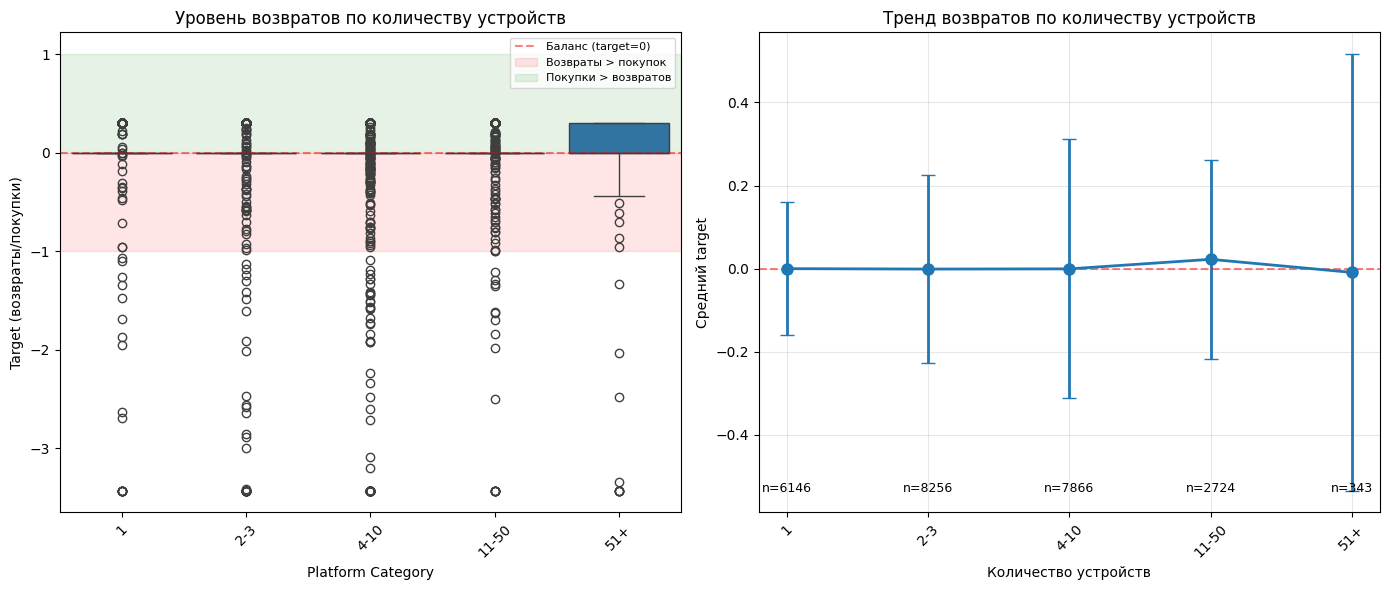

In [33]:
print("\nВизуализация результатов:")

# Подготовка данных для визуализации
viz_data = []
for group_name, indices in platform_groups_dict.items():
    group_targets = df.loc[indices, 'target'].dropna()
    if len(group_targets) > 0:
        for target in group_targets:
            viz_data.append({
                'Platform Category': group_name,
                'Target': target,
                'Devices': group_name,
                'Return Level': 'Высокие возвраты' if target < -0.2 else 
                              'Средние возвраты' if target < 0.2 else 
                              'Низкие возвраты'
            })

if viz_data:
    viz_df = pd.DataFrame(viz_data)
    
    # Упорядочиваем категории
    ordered_categories = ['1', '2-3', '4-10', '11-50', '51+']
    present_categories = [cat for cat in ordered_categories if cat in viz_df['Platform Category'].unique()]
    
    if present_categories:
        # Boxplot
        plt.figure(figsize=(14, 6))
        
        plt.subplot(1, 2, 1)
        sns.boxplot(x='Platform Category', y='Target', data=viz_df, 
                   order=present_categories)
        plt.title('Уровень возвратов по количеству устройств')
        plt.xticks(rotation=45)
        plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Баланс (target=0)')
        plt.axhspan(-1, 0, alpha=0.1, color='red', label='Возвраты > покупок')
        plt.axhspan(0, 1, alpha=0.1, color='green', label='Покупки > возвратов')
        plt.ylabel('Target (возвраты/покупки)')
        plt.legend(loc='upper right', fontsize=8)
        
        # Line plot тренда
        plt.subplot(1, 2, 2)
        trend_means = viz_df.groupby('Platform Category')['Target'].mean().reindex(present_categories)
        trend_stds = viz_df.groupby('Platform Category')['Target'].std().reindex(present_categories)
        trend_counts = viz_df.groupby('Platform Category').size().reindex(present_categories)
        
        plt.errorbar(range(len(trend_means)), trend_means.values, 
                   yerr=trend_stds.values, fmt='o-', capsize=5, linewidth=2, markersize=8)
        plt.xticks(range(len(trend_means)), present_categories, rotation=45)
        plt.title('Тренд возвратов по количеству устройств')
        plt.xlabel('Количество устройств')
        plt.ylabel('Средний target')
        plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        plt.grid(True, alpha=0.3)
        
        # Добавляем количество наблюдений
        for i, count in enumerate(trend_counts.values):
            plt.text(i, plt.ylim()[0] + 0.05, f'n={count}', 
                    ha='center', fontsize=9)
        
        plt.tight_layout()
        plt.show()

## Вывод
ПРОБЛЕМНАЯ КАТЕГОРИЯ (наибольшие возвраты): '51+'
   • Средний target: -0.0090
   • Интерпретация: Умеренные возвраты
   • Количество пользователей: 343

ЛУЧШАЯ КАТЕГОРИЯ (наименьшие возвраты): '11-50'
   • Средний target: 0.0225
   • Интерпретация: Низкие возвраты
   • Количество пользователей: 2724

СРАВНЕНИЕ КРАЙНИХ КАТЕГОРИЙ:
   • 1 устройство: target=-0.0000
   • 51+ устройств: target=-0.0090
   • Разница: 0.0090

СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ:
   • Тест: Kruskal-Wallis
   • p-value: 0.000000
   • Результат: есть статистически значимые различия

РЕКОМЕНДАЦИИ ПО УПРАВЛЕНИЮ ВОЗВРАТАМИ:
   1. Есть статистически значимые различия по количеству устройств
   2. Сфокусироваться на проблемных категориях: 51+
   3. Исследовать причины высоких возвратов у 51+
   4. Перенять лучшие практики из категории: 11-50

## Гипотеза 3. Время жизни пользователя с Z-score разделением
H₁: 'Свежие' клиенты (низкий user_lifetime) чаще возвращают

H₂: Клиенты с долгим принятием решения (высокий days_to_first_buy) реже возвращают

### Проверка

In [34]:
def create_zscore_groups(data_series, group_names=['Низкий', 'Средний', 'Высокий'], 
                         thresholds=[-1, 1]):
    """
    Создает группы на основе Z-score
    thresholds: пороги для разделения (по умолчанию: -1, 1)
    """
    z_scores = zscore(data_series.fillna(data_series.median()))
    
    conditions = [
        z_scores <= thresholds[0],  # Низкий Z-score
        (z_scores > thresholds[0]) & (z_scores <= thresholds[1]),  # Средний Z-score
        z_scores > thresholds[1]  # Высокий Z-score
    ]
    
    return pd.cut(z_scores, bins=[-np.inf, thresholds[0], thresholds[1], np.inf], 
                  labels=group_names)

def analyze_groups_statistically(groups_dict, target_var='target', test_type='kruskal'):
    """
    Анализирует статистическую значимость различий между группами
    """
    print("\nСтатистический анализ групп:")
    
    # Собираем данные по группам
    group_data = []
    group_stats = []
    
    for group_name, group_indices in groups_dict.items():
        group_values = df.loc[group_indices, target_var].dropna()
        if len(group_values) > 0:
            group_data.append(group_values)
            group_stats.append({
                'Группа': group_name,
                'N': len(group_values),
                'Среднее': group_values.mean(),
                'Медиана': group_values.median(),
                'Std': group_values.std(),
                'Min': group_values.min(),
                'Max': group_values.max()
            })
    
    # Выводим статистику
    stats_df = pd.DataFrame(group_stats)
    print(stats_df.round(4).to_string(index=False))
    
    # Проверка нормальности
    print("\nПроверка нормальности:")
    normality_results = []
    for i, group_vals in enumerate(group_data):
        if len(group_vals) > 3:
            if len(group_vals) < 5000:
                _, p = shapiro(group_vals)
            else:
                _, p = normaltest(group_vals)
            normality_results.append(p > 0.05)
            print(f"  Группа {list(groups_dict.keys())[i]}: p={p:.4f} ({'нормальное' if p > 0.05 else 'не нормальное'})")
    
    # Выбор и проведение теста
    if all(normality_results) and len(group_data) > 1:
        print("\nВсе группы нормальные, применяем ANOVA")
        f_stat, p_val = f_oneway(*group_data)
        test_type = "ANOVA"
        test_stat = f_stat
    elif len(group_data) > 1:
        print("\nНе все группы нормальные, применяем Kruskal-Wallis")
        h_stat, p_val = kruskal(*group_data)
        test_type = "Kruskal-Wallis"
        test_stat = h_stat
    else:
        print("\nНедостаточно групп для сравнения")
        return None, None, None
    
    print(f"\n{test_type}:")
    print(f"Статистика: {test_stat:.4f}")
    print(f"p-value: {p_val:.6f}")
    
    return stats_df, test_type, p_val

def plot_group_comparison(groups_dict, target_var='target', title='Сравнение групп'):
    """
    Визуализация сравнения групп
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(title, fontweight='bold')
    
    # Подготовка данных для визуализации
    plot_data = []
    for group_name, group_indices in groups_dict.items():
        values = df.loc[group_indices, target_var].dropna()
        plot_data.append(pd.DataFrame({
            'Группа': group_name,
            'Значение': values
        }))
    
    plot_df = pd.concat(plot_data, ignore_index=True)
    
    # Boxplot
    ax1 = axes[0, 0]
    sns.boxplot(x='Группа', y='Значение', data=plot_df, ax=ax1, 
                order=list(groups_dict.keys()))
    ax1.set_title('Boxplot сравнения групп')
    ax1.set_xlabel('Группа')
    ax1.set_ylabel(target_var)
    ax1.tick_params(axis='x', rotation=45)
    ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    
    # Violin plot
    ax2 = axes[0, 1]
    sns.violinplot(x='Группа', y='Значение', data=plot_df, ax=ax2,
                   order=list(groups_dict.keys()))
    ax2.set_title('Violin plot распределений')
    ax2.set_xlabel('Группа')
    ax2.set_ylabel(target_var)
    ax2.tick_params(axis='x', rotation=45)
    ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    
    # Bar plot средних значений
    ax3 = axes[1, 0]
    means = plot_df.groupby('Группа')['Значение'].mean().reindex(list(groups_dict.keys()))
    stds = plot_df.groupby('Группа')['Значение'].std().reindex(list(groups_dict.keys()))
    
    bars = ax3.bar(range(len(means)), means.values, yerr=stds.values, 
                   capsize=5, alpha=0.7, edgecolor='black')
    ax3.set_xticks(range(len(means)))
    ax3.set_xticklabels(means.index, rotation=45)
    ax3.set_title('Средние значения по группам с std')
    ax3.set_ylabel(f'Средний {target_var}')
    ax3.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    
    # Добавляем значения на столбцы
    for i, (bar, mean_val) in enumerate(zip(bars, means.values)):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + (0.01 if height >= 0 else -0.02),
                f'{mean_val:.3f}', ha='center', va='bottom' if height >= 0 else 'top')
    
    # Гистограммы распределений
    ax4 = axes[1, 1]
    for group_name in groups_dict.keys():
        group_values = plot_df[plot_df['Группа'] == group_name]['Значение']
        ax4.hist(group_values, bins=30, alpha=0.5, label=group_name, density=True)
    
    ax4.set_title('Наложенные распределения по группам')
    ax4.set_xlabel(target_var)
    ax4.set_ylabel('Плотность')
    ax4.legend()
    ax4.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Очистка данных
df_time = df.copy()
df_time = df_time[df_time['user_lifetime'].notna() & (df_time['user_lifetime'] >= 0)]
df_time = df_time[df_time['days_to_first_buy'].notna() & (df_time['days_to_first_buy'] >= 0)]

# Рассчитываем Z-score для временных переменных
df_time['lifetime_z'] = zscore(df_time['user_lifetime'])
df_time['firstbuy_z'] = zscore(df_time['days_to_first_buy'])

# Создаем группы на основе Z-score
print("\nСоздание групп на основе z-score:")

# 3.1. Группы по user_lifetime (время с первого входа)
df_time['lifetime_group'] = create_zscore_groups(
    df_time['user_lifetime'],
    group_names=['Новые', 'Средние', 'Старые'],
    thresholds=[-0.5, 0.5]
)

lifetime_groups_dict = {}
for group in ['Новые', 'Средние', 'Старые']:
    lifetime_groups_dict[group] = df_time[df_time['lifetime_group'] == group].index

print("Группы по user_lifetime (Z-score):")
for group, indices in lifetime_groups_dict.items():
    print(f"  {group}: {len(indices)} пользователей")

# 3.2. Группы по days_to_first_buy (время до первой покупки)
df_time['firstbuy_group'] = create_zscore_groups(
    df_time['days_to_first_buy'],
    group_names=['Быстрые', 'Средние', 'Медленные'],
    thresholds=[-0.5, 0.5]
)

firstbuy_groups_dict = {}
for group in ['Быстрые', 'Средние', 'Медленные']:
    firstbuy_groups_dict[group] = df_time[df_time['firstbuy_group'] == group].index

print("\nГруппы по days_to_first_buy (Z-score):")
for group, indices in firstbuy_groups_dict.items():
    print(f"  {group}: {len(indices)} пользователей")


Создание групп на основе z-score:
Группы по user_lifetime (Z-score):
  Новые: 4503 пользователей
  Средние: 8109 пользователей
  Старые: 4206 пользователей

Группы по days_to_first_buy (Z-score):
  Быстрые: 9828 пользователей
  Средние: 3462 пользователей
  Медленные: 3528 пользователей


### Визуализация

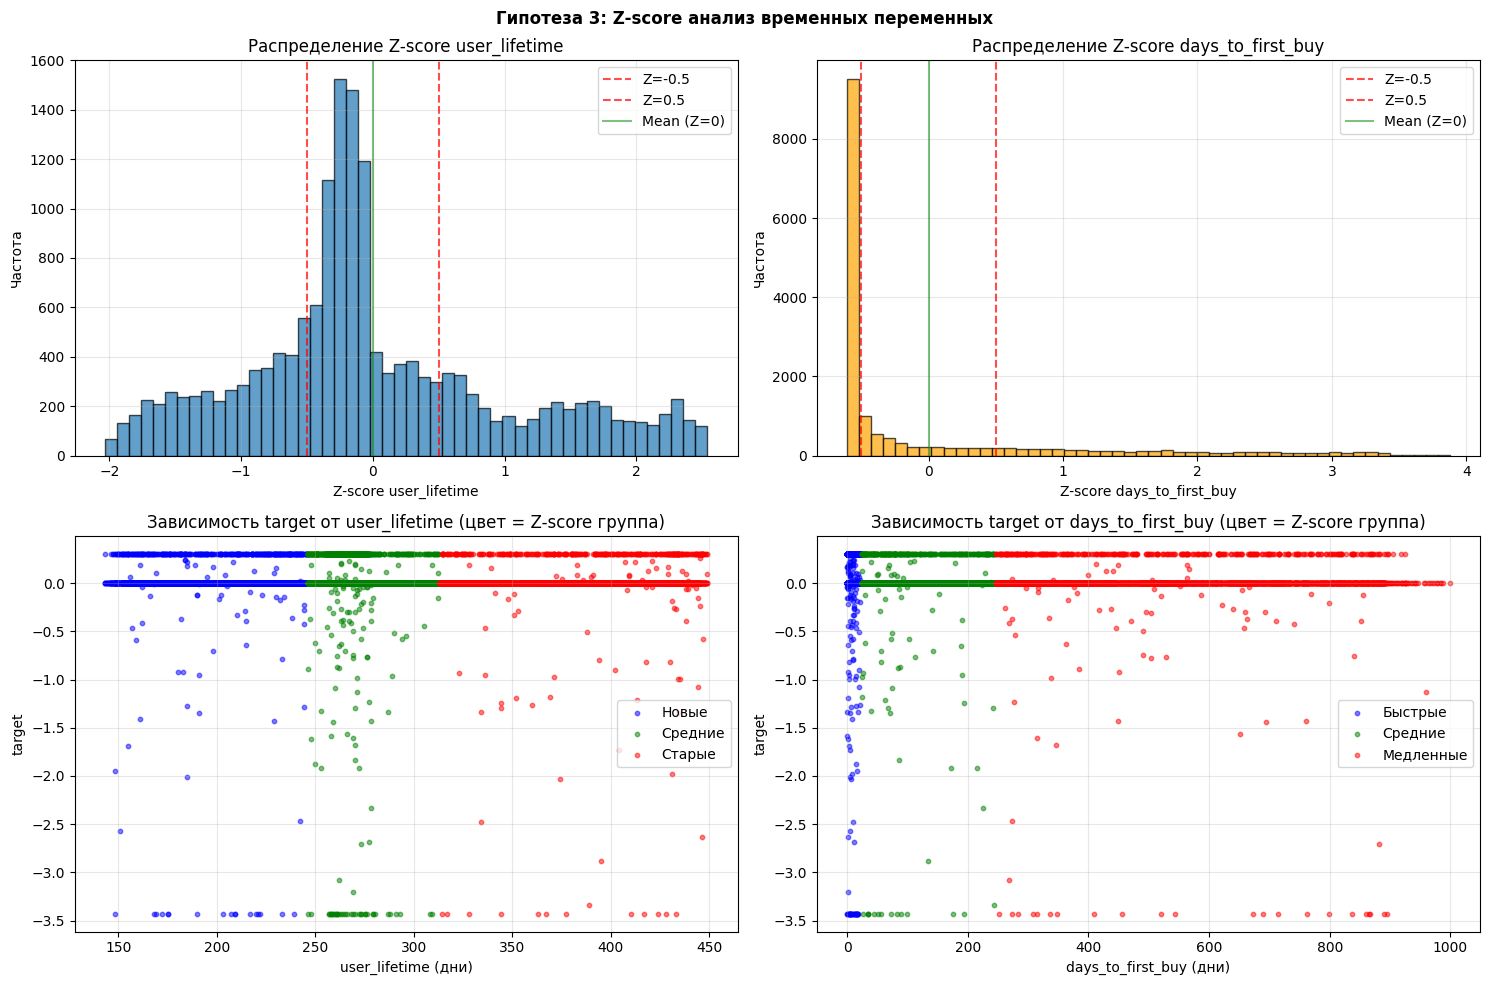

Статистический анализ групп по user_lifetime:

Статистический анализ групп:
 Группа    N  Среднее  Медиана    Std     Min  Max
  Новые 4503   0.0066      0.0 0.2461 -3.4286  0.3
Средние 8109  -0.0008      0.0 0.2683 -3.4286  0.3
 Старые 4206   0.0055      0.0 0.2381 -3.4286  0.3

Проверка нормальности:
  Группа Новые: p=0.0000 (не нормальное)
  Группа Средние: p=0.0000 (не нормальное)
  Группа Старые: p=0.0000 (не нормальное)

Не все группы нормальные, применяем Kruskal-Wallis

Kruskal-Wallis:
Статистика: 6.1840
p-value: 0.045412


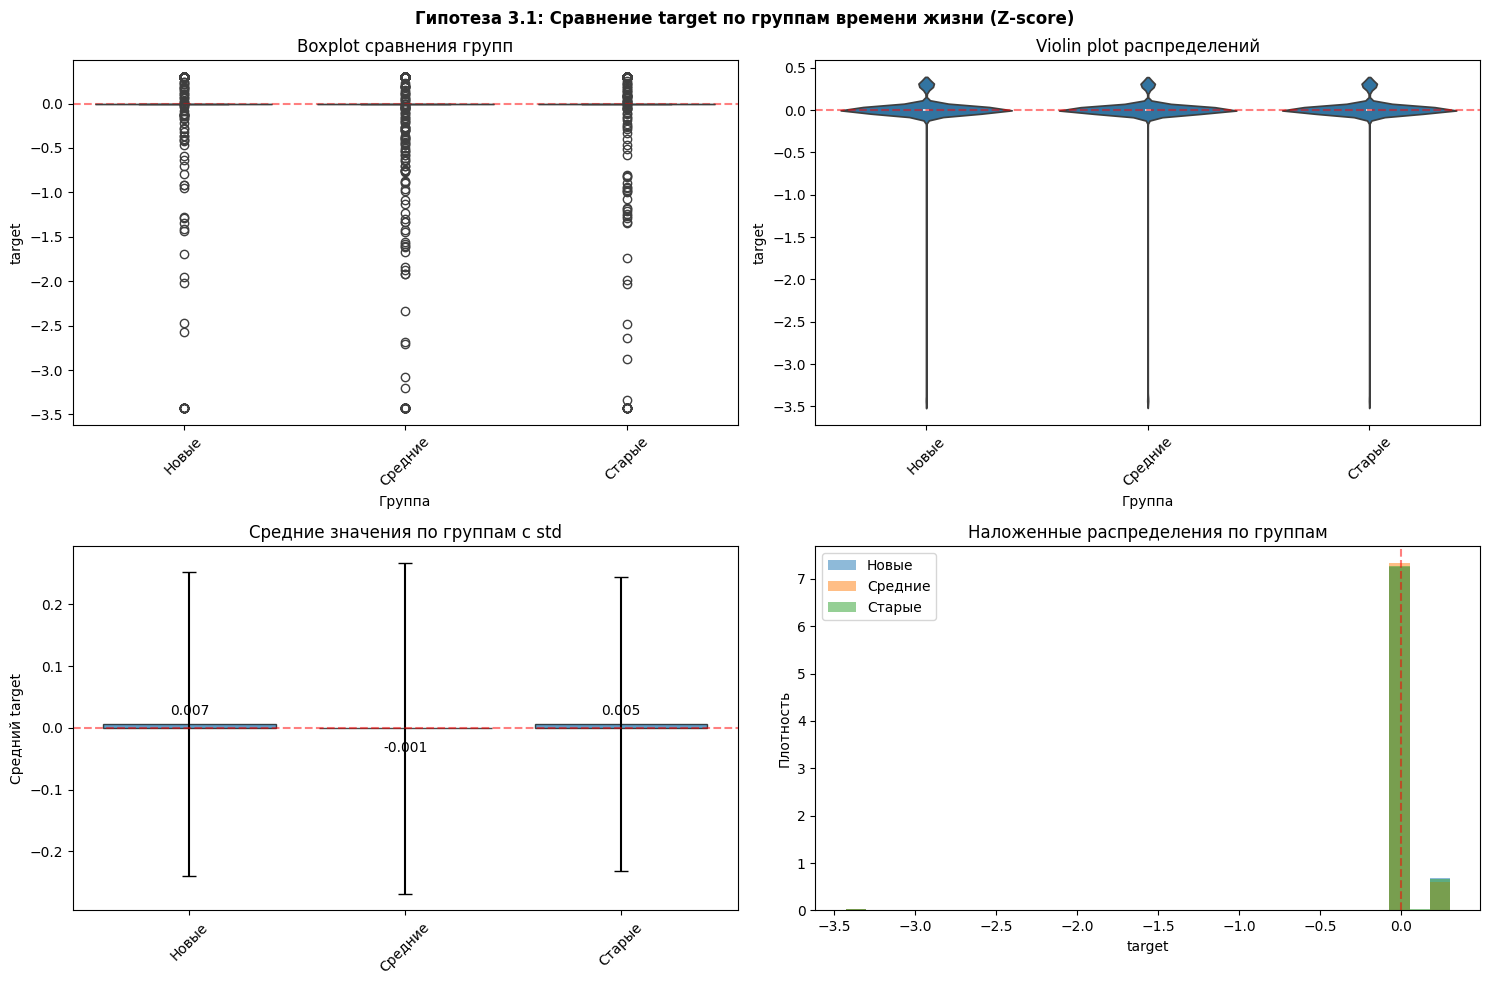

Статистический анализ групп по days_to_first_buy:

Статистический анализ групп:
   Группа    N  Среднее  Медиана    Std     Min  Max
  Быстрые 9828   0.0042      0.0 0.2300 -3.4286  0.3
  Средние 3462   0.0025      0.0 0.2612 -3.4286  0.3
Медленные 3528  -0.0010      0.0 0.3099 -3.4286  0.3

Проверка нормальности:
  Группа Быстрые: p=0.0000 (не нормальное)
  Группа Средние: p=0.0000 (не нормальное)
  Группа Медленные: p=0.0000 (не нормальное)

Не все группы нормальные, применяем Kruskal-Wallis

Kruskal-Wallis:
Статистика: 13.0100
p-value: 0.001496


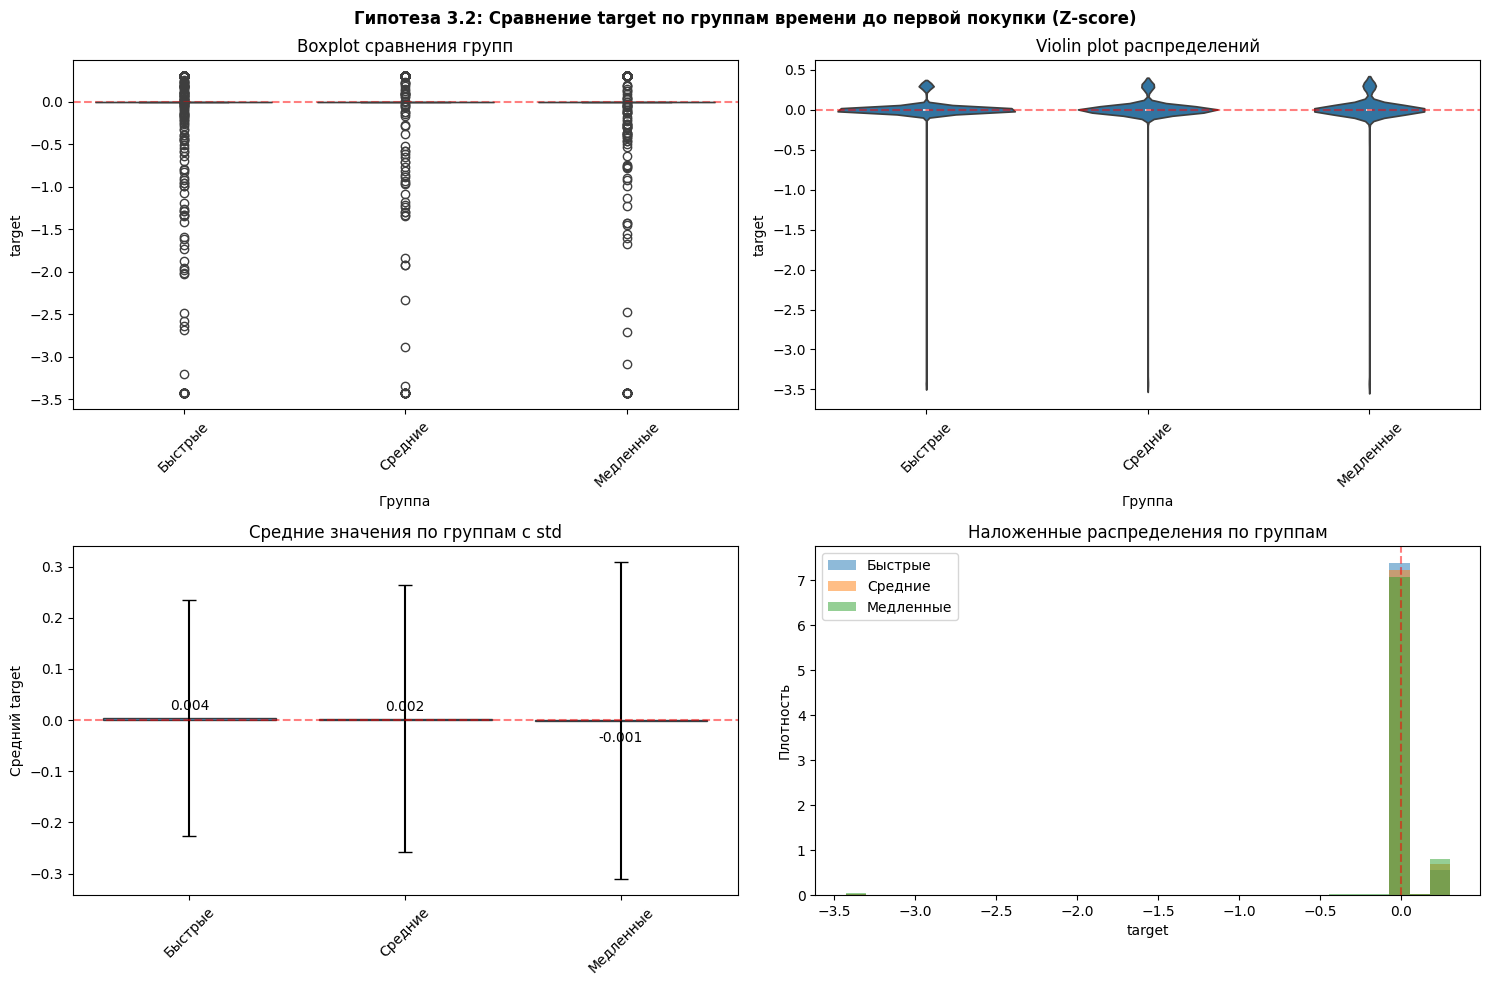

Корреляционный анализ с Z-score:
Корреляция Z-score user_lifetime с target: 0.0029
Корреляция Z-score days_to_first_buy с target: -0.0103
Сравнение экстремальных групп (крайние 20%):

user_lifetime:
Нижние 10% (самые новые): n=1647, target=0.0062
Верхние 10% (самые старые): n=1671, target=0.0095
Разница: 0.0033

days_to_first_buy:
Нижние 10% (самые быстрые): n=1621, target=0.0125
Верхние 10% (самые медленные): n=1672, target=-0.0029
Разница: -0.0154

user_lifetime (экстремальные группы) U-test p-value: 0.410475
days_to_first_buy (экстремальные группы) U-test p-value: 0.057343
Вывод по гипотезе 3:

Гипотеза 3.1: Свежие' клиенты чаще возвращают
ГИПОТЕЗА ОПРОВЕРГНУТА
Новые пользователи имеют БОЛЬШИЙ target (0.0066 vs 0.0055)

МЕТРИКИ 3.1:
Kruskal-Wallis p-value: 0.045412
Корреляция Z-score: 0.0029

Гипотеза 3.2: Клиенты с долгим принятием решения реже возвращают
ГИПОТЕЗА ОПРОВЕРГНУТА
Медленные покупатели имеют МЕНЬШИЙ target (-0.0010 vs 0.0042)

МЕТРИКИ 3.2:
Kruskal-Wallis p-value: 0.0014

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Гипотеза 3: Z-score анализ временных переменных', fontweight='bold')

# 1. Распределение Z-score user_lifetime
ax1 = axes[0, 0]
ax1.hist(df_time['lifetime_z'], bins=50, alpha=0.7, edgecolor='black')
ax1.axvline(x=-0.5, color='red', linestyle='--', alpha=0.7, label='Z=-0.5')
ax1.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Z=0.5')
ax1.axvline(x=0, color='green', linestyle='-', alpha=0.5, label='Mean (Z=0)')
ax1.set_xlabel('Z-score user_lifetime')
ax1.set_ylabel('Частота')
ax1.set_title('Распределение Z-score user_lifetime')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Распределение Z-score days_to_first_buy
ax2 = axes[0, 1]
ax2.hist(df_time['firstbuy_z'], bins=50, alpha=0.7, edgecolor='black', color='orange')
ax2.axvline(x=-0.5, color='red', linestyle='--', alpha=0.7, label='Z=-0.5')
ax2.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Z=0.5')
ax2.axvline(x=0, color='green', linestyle='-', alpha=0.5, label='Mean (Z=0)')
ax2.set_xlabel('Z-score days_to_first_buy')
ax2.set_ylabel('Частота')
ax2.set_title('Распределение Z-score days_to_first_buy')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Scatter plot с цветом по группам lifetime
ax3 = axes[1, 0]
for group, color in zip(['Новые', 'Средние', 'Старые'], ['blue', 'green', 'red']):
    group_indices = lifetime_groups_dict[group]
    ax3.scatter(df_time.loc[group_indices, 'user_lifetime'], 
                df_time.loc[group_indices, 'target'],
                alpha=0.5, s=10, label=group, color=color)
ax3.set_xlabel('user_lifetime (дни)')
ax3.set_ylabel('target')
ax3.set_title('Зависимость target от user_lifetime (цвет = Z-score группа)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Scatter plot с цветом по группам firstbuy
ax4 = axes[1, 1]
for group, color in zip(['Быстрые', 'Средние', 'Медленные'], ['blue', 'green', 'red']):
    group_indices = firstbuy_groups_dict[group]
    ax4.scatter(df_time.loc[group_indices, 'days_to_first_buy'], 
            df_time.loc[group_indices, 'target'],
            alpha=0.5, s=10, label=group, color=color)
ax4.set_xlabel('days_to_first_buy (дни)')
ax4.set_ylabel('target')
ax4.set_title('Зависимость target от days_to_first_buy (цвет = Z-score группа)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Статистический анализ групп
print("Статистический анализ групп по user_lifetime:")

stats_lifetime, test_lifetime, p_lifetime = analyze_groups_statistically(
    lifetime_groups_dict,
    target_var='target',
    test_type='kruskal'
)

plot_group_comparison(
    lifetime_groups_dict,
    target_var='target',
    title='Гипотеза 3.1: Сравнение target по группам времени жизни (Z-score)'
)

print("Статистический анализ групп по days_to_first_buy:")

stats_firstbuy, test_firstbuy, p_firstbuy = analyze_groups_statistically(
    firstbuy_groups_dict,
    target_var='target',
    test_type='kruskal'
)

plot_group_comparison(
    firstbuy_groups_dict,
    target_var='target',
    title='Гипотеза 3.2: Сравнение target по группам времени до первой покупки (Z-score)'
)

# Корреляционный анализ с Z-score
print("Корреляционный анализ с Z-score:")

corr_lifetime = df_time['lifetime_z'].corr(df_time['target'])
corr_firstbuy = df_time['firstbuy_z'].corr(df_time['target'])

print(f"Корреляция Z-score user_lifetime с target: {corr_lifetime:.4f}")
print(f"Корреляция Z-score days_to_first_buy с target: {corr_firstbuy:.4f}")

# Сравнение экстремальных групп (крайние 20%)
print("Сравнение экстремальных групп (крайние 20%):")

# Берем нижние и верхние 10% по Z-score
lifetime_low = df_time[df_time['lifetime_z'] < df_time['lifetime_z'].quantile(0.1)]['target'].dropna()
lifetime_high = df_time[df_time['lifetime_z'] > df_time['lifetime_z'].quantile(0.9)]['target'].dropna()

firstbuy_low = df_time[df_time['firstbuy_z'] < df_time['firstbuy_z'].quantile(0.1)]['target'].dropna()
firstbuy_high = df_time[df_time['firstbuy_z'] > df_time['firstbuy_z'].quantile(0.9)]['target'].dropna()

print(f"\nuser_lifetime:")
print(f"Нижние 10% (самые новые): n={len(lifetime_low)}, target={lifetime_low.mean():.4f}")
print(f"Верхние 10% (самые старые): n={len(lifetime_high)}, target={lifetime_high.mean():.4f}")
print(f"Разница: {lifetime_high.mean() - lifetime_low.mean():.4f}")

print(f"\ndays_to_first_buy:")
print(f"Нижние 10% (самые быстрые): n={len(firstbuy_low)}, target={firstbuy_low.mean():.4f}")
print(f"Верхние 10% (самые медленные): n={len(firstbuy_high)}, target={firstbuy_high.mean():.4f}")
print(f"Разница: {firstbuy_high.mean() - firstbuy_low.mean():.4f}")

# Статистические тесты для экстремальных групп
if len(lifetime_low) > 10 and len(lifetime_high) > 10:
    u_stat_lifetime, p_val_lifetime_extreme = mannwhitneyu(lifetime_low, lifetime_high)
    print(f"\nuser_lifetime (экстремальные группы) U-test p-value: {p_val_lifetime_extreme:.6f}")

if len(firstbuy_low) > 10 and len(firstbuy_high) > 10:
    u_stat_firstbuy, p_val_firstbuy_extreme = mannwhitneyu(firstbuy_low, firstbuy_high)
    print(f"days_to_first_buy (экстремальные группы) U-test p-value: {p_val_firstbuy_extreme:.6f}")

# Вывод по гипотезе 3
print("Вывод по гипотезе 3:")

print("\nГипотеза 3.1: Свежие' клиенты чаще возвращают")
if p_lifetime < 0.05:
    group_means_lifetime = stats_lifetime.set_index('Группа')['Среднее']
    newest_mean = group_means_lifetime['Новые'] if 'Новые' in group_means_lifetime.index else None
    oldest_mean = group_means_lifetime['Старые'] if 'Старые' in group_means_lifetime.index else None
    
    if newest_mean is not None and oldest_mean is not None:
        if newest_mean < oldest_mean:
            print("ГИПОТЕЗА ПОДТВЕРЖДЕНА")
            print(f"Новые пользователи имеют МЕНЬШИЙ target ({newest_mean:.4f} vs {oldest_mean:.4f})")
        else:
            print("ГИПОТЕЗА ОПРОВЕРГНУТА")
            print(f"Новые пользователи имеют БОЛЬШИЙ target ({newest_mean:.4f} vs {oldest_mean:.4f})")
else:
    print("ГИПОТЕЗА НЕ ПОДТВЕРЖДЕНА")
    print(f"Нет статистически значимых различий (p={p_lifetime:.6f})")

print(f"\nМЕТРИКИ 3.1:")
print(f"Kruskal-Wallis p-value: {p_lifetime:.6f}")
print(f"Корреляция Z-score: {corr_lifetime:.4f}")

print("\nГипотеза 3.2: Клиенты с долгим принятием решения реже возвращают")
if p_firstbuy < 0.05:
    group_means_firstbuy = stats_firstbuy.set_index('Группа')['Среднее']
    fast_mean = group_means_firstbuy['Быстрые'] if 'Быстрые' in group_means_firstbuy.index else None
    slow_mean = group_means_firstbuy['Медленные'] if 'Медленные' in group_means_firstbuy.index else None
    
    if fast_mean is not None and slow_mean is not None:
        if slow_mean > fast_mean:
            print("ГИПОТЕЗА ПОДТВЕРЖДЕНА")
            print(f"Медленные покупатели имеют БОЛЬШИЙ target ({slow_mean:.4f} vs {fast_mean:.4f})")
        else:
            print("ГИПОТЕЗА ОПРОВЕРГНУТА")
            print(f"Медленные покупатели имеют МЕНЬШИЙ target ({slow_mean:.4f} vs {fast_mean:.4f})")
else:
    print("ГИПОТЕЗА НЕ ПОДТВЕРЖДЕНА")
    print(f"Нет статистически значимых различий (p={p_firstbuy:.6f})")

print(f"\nМЕТРИКИ 3.2:")
print(f"Kruskal-Wallis p-value: {p_firstbuy:.6f}")
print(f"Корреляция Z-score: {corr_firstbuy:.4f}")

# Вывод
ГИПОТЕЗА 3.1: 'Свежие' клиенты чаще возвращают    
ГИПОТЕЗА ОПРОВЕРГНУТА  
Новые пользователи имеют БОЛЬШИЙ target (0.0066 vs 0.0055)  

МЕТРИКИ 3.1:  
Kruskal-Wallis p-value: 0.045412  
Корреляция Z-score: 0.0029  

ГИПОТЕЗА 3.2: Клиенты с долгим принятием решения реже возвращают  
ГИПОТЕЗА ОПРОВЕРГНУТА  
Медленные покупатели имеют МЕНЬШИЙ target (-0.0010 vs 0.0042)  

МЕТРИКИ 3.2:  
Kruskal-Wallis p-value: 0.001496  
Корреляция Z-score: -0.0103  

## Гипотеза 4. Ловушка лояльности с Z-score разделением по total_buy

H₀: total_buy и total_return независимы  
H₁: Пользователи с высоким total_buy также имеют высокий total_return

### Проверка

In [37]:
# Рассчитываем Z-score
df['total_buy_z'] = zscore(df['total_buy'].fillna(df['total_buy'].median()))

# Создаем группы на основе Z-score
def create_zscore_groups(series, thresholds=[-0.5, 0.5], group_names=None):
    if group_names is None:
        group_names = ['Low', 'Medium', 'High']
    return pd.cut(series, bins=[-np.inf] + thresholds + [np.inf], labels=group_names)

df['buy_group'] = create_zscore_groups(
    df['total_buy_z'],
    thresholds=[-0.5, 0.5],
    group_names=['Низкие траты', 'Средние траты', 'Высокие траты']
)

buy_groups_dict = {group: df[df['buy_group'] == group].index.tolist()
                   for group in ['Низкие траты', 'Средние траты', 'Высокие траты']}

print("\nРаспроделение по группам total_buy (Z-score):")
for group, indices in buy_groups_dict.items():
    print(f"{group}: {len(indices)} пользователей ({len(indices)/len(df)*100:.1f}%)")

# Статистический анализ групп по target
print("Анализ групп по target:")

stats_target, test_target, p_target = analyze_groups_statistically(
    buy_groups_dict,
    target_var='target',
    test_type='kruskal'
)

# Анализ групп по total_return (абсолютные значения)
print("Анализ групп по total_return:")

stats_return, test_return, p_return = analyze_groups_statistically(
    buy_groups_dict,
    target_var='total_return',
    test_type='kruskal'
)

# Анализ групп по buy_return_ratio (процент возвратов)
print("Анализ групп по buy_return_ratio (total_return/total_buy):")

stats_ratio, test_ratio, p_ratio = analyze_groups_statistically(
    buy_groups_dict,
    target_var='buy_return_ratio',
    test_type='kruskal'
)


Распроделение по группам total_buy (Z-score):
Низкие траты: 0 пользователей (0.0%)
Средние траты: 24435 пользователей (96.4%)
Высокие траты: 900 пользователей (3.6%)
Анализ групп по target:

Статистический анализ групп:
       Группа     N  Среднее  Медиана    Std     Min  Max
Средние траты 24435   0.0035      0.0 0.2308 -3.4286  0.3
Высокие траты   900  -0.0443      0.0 0.5738 -3.4286  0.3

Проверка нормальности:
  Группа Низкие траты: p=0.0000 (не нормальное)
  Группа Средние траты: p=0.0000 (не нормальное)

Не все группы нормальные, применяем Kruskal-Wallis

Kruskal-Wallis:
Статистика: 153.3505
p-value: 0.000000
Анализ групп по total_return:

Статистический анализ групп:
       Группа     N   Среднее   Медиана        Std  Min        Max
Средние траты 24435   80.6969    0.0000   396.8791  0.0  30602.033
Высокие траты   900 7213.5004 3423.1572 13446.4147  0.0 207893.840

Проверка нормальности:
  Группа Низкие траты: p=0.0000 (не нормальное)
  Группа Средние траты: p=0.0000 (не нормал

### Визуализация


Распределение пользователей по группам total_buy:
Низкие траты: 8361 пользователей (33.0%)
Средние траты: 8360 пользователей (33.0%)
Высокие траты: 8614 пользователей (34.0%)


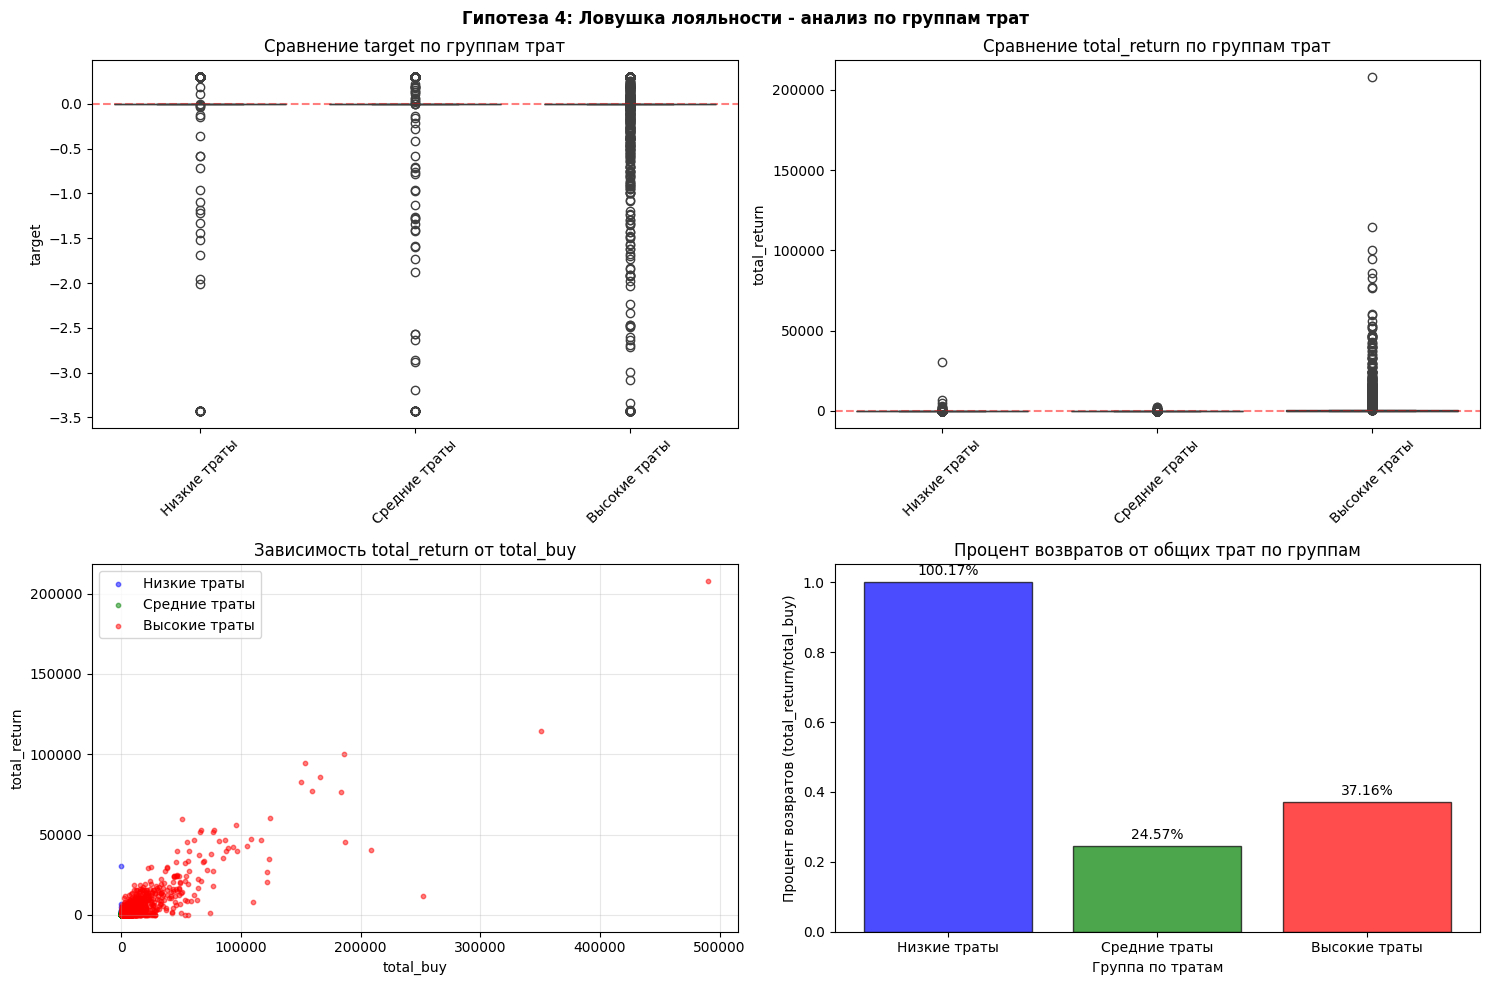

Корреляционный анализ с Z-score:
Корреляция total_buy с total_return: 0.8928
Корреляция Z-score total_buy с Z-score total_return: 0.8928
Корреляция total_buy с target: -0.0145
Корреляция total_return с target: -0.0247
Анализ "ловушки лояльности":

Статистика по типам пользователей:
                          user_id  total_buy  total_return  target  \
user_type                                                            
Активные покупатели           109  15126.757      1068.286   0.000   
Активные с возвратами         199  25027.910     12243.730   0.000   
Активные, но не лояльные       71  27474.916     12297.136  -1.175   
Лояльные активные             176  35033.021     13034.091   0.267   
Прочие                      24780    323.602       110.732   0.003   

                          buy_return_ratio  
user_type                                   
Активные покупатели                  0.092  
Активные с возвратами                0.560  
Активные, но не лояльные             0.424  
Л

In [38]:
# Рассчитываем Z-score для total_buy и total_return
df['total_buy_z'] = zscore(df['total_buy'].fillna(df['total_buy'].median()))
df['total_return_z'] = zscore(df['total_return'].fillna(df['total_return'].median()))

# Создаем группы по total_buy с использованием квантилей (чтобы группы были непустые)
quantiles = df['total_buy'].quantile([0.33, 0.66]).values
group_names = ['Низкие траты', 'Средние траты', 'Высокие траты']

df['buy_group'] = pd.cut(df['total_buy'], bins=[-np.inf] + list(quantiles) + [np.inf],
                         labels=group_names)

# Проверяем распределение по группам
buy_groups_dict = {group: df[df['buy_group'] == group].index.tolist() for group in group_names}
print("\nРаспределение пользователей по группам total_buy:")
for group, indices in buy_groups_dict.items():
    print(f"{group}: {len(indices)} пользователей ({len(indices)/len(df)*100:.1f}%)")

# -----------------------------
# Визуализация 4 графиков
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Гипотеза 4: Ловушка лояльности - анализ по группам трат', fontweight='bold')

# 1. Boxplot target по группам
ax1 = axes[0, 0]
sns.boxplot(x='buy_group', y='target', data=df, ax=ax1)
ax1.set_title('Сравнение target по группам трат')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=45)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)

# 2. Boxplot total_return по группам
ax2 = axes[0, 1]
sns.boxplot(x='buy_group', y='total_return', data=df, ax=ax2)
ax2.set_title('Сравнение total_return по группам трат')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)

# 3. Scatter plot total_buy vs total_return с цветом по группам
ax3 = axes[1, 0]
colors = {'Низкие траты': 'blue', 'Средние траты': 'green', 'Высокие траты': 'red'}
for group, color in colors.items():
    group_indices = buy_groups_dict[group]
    ax3.scatter(df.loc[group_indices, 'total_buy'], 
                df.loc[group_indices, 'total_return'],
                alpha=0.5, s=10, label=group, color=color)
ax3.set_xlabel('total_buy')
ax3.set_ylabel('total_return')
ax3.set_title('Зависимость total_return от total_buy')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Процент возвратов по группам
ax4 = axes[1, 1]
return_ratios = []
for group in group_names:
    group_indices = buy_groups_dict[group]
    group_buy = df.loc[group_indices, 'total_buy'].sum()
    group_return = df.loc[group_indices, 'total_return'].sum()
    return_ratio = group_return / group_buy if group_buy > 0 else 0
    return_ratios.append(return_ratio)

bars = ax4.bar(group_names, return_ratios, color=['blue', 'green', 'red'], alpha=0.7, edgecolor='black')
ax4.set_xlabel('Группа по тратам')
ax4.set_ylabel('Процент возвратов (total_return/total_buy)')
ax4.set_title('Процент возвратов от общих трат по группам')

# Добавляем значения на столбцы
for bar, ratio in zip(bars, return_ratios):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{ratio:.2%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


# Корреляционный анализ с Z-score
print("Корреляционный анализ с Z-score:")

corr_buy_return = df['total_buy'].corr(df['total_return'])
corr_buy_return_z = df['total_buy_z'].corr(df['total_return_z'])
corr_buy_target = df['total_buy'].corr(df['target'])
corr_return_target = df['total_return'].corr(df['target'])

print(f"Корреляция total_buy с total_return: {corr_buy_return:.4f}")
print(f"Корреляция Z-score total_buy с Z-score total_return: {corr_buy_return_z:.4f}")
print(f"Корреляция total_buy с target: {corr_buy_target:.4f}")
print(f"Корреляция total_return с target: {corr_return_target:.4f}")

# Анализ "ловушки лояльности"
print('Анализ "ловушки лояльности":')

# Создаем категории пользователей
df['user_type'] = 'Прочие'
df.loc[df['total_buy_z'] > 1, 'user_type'] = 'Активные покупатели'
df.loc[(df['total_buy_z'] > 1) & (df['total_return_z'] > 1), 'user_type'] = 'Активные с возвратами'
df.loc[(df['total_buy_z'] > 1) & (df['target'] > 0), 'user_type'] = 'Лояльные активные'
df.loc[(df['total_buy_z'] > 1) & (df['target'] < 0), 'user_type'] = 'Активные, но не лояльные'

user_type_stats = df.groupby('user_type').agg({
    'user_id': 'count',
    'total_buy': 'mean',
    'total_return': 'mean',
    'target': 'mean',
    'buy_return_ratio': 'mean'
}).round(3)

print("\nСтатистика по типам пользователей:")
print(user_type_stats)

# Анализ доли "активных, но не лояльных"
active_unloyal = df[df['user_type'] == 'Активные, но не лояльные']
if len(active_unloyal) > 0:
    print(f"\nЛовушка лояльности обнаружена!")
    print(f"Количество 'активных, но не лояльных' пользователей: {len(active_unloyal)}")
    print(f"Их доля среди всех пользователей: {len(active_unloyal)/len(df)*100:.1f}%")
    print(f"Их средний target: {active_unloyal['target'].mean():.4f}")
    print(f"Их процент возвратов: {active_unloyal['buy_return_ratio'].mean():.2%}")

# Вывод

ГИПОТЕЗА ПОДТВЕРЖДЕНА    
Существует статистически значимая ПОЛОЖИТЕЛЬНАЯ корреляция  
Пользователи с высоким total_buy действительно имеют высокий total_return  

КРИТИЧЕСКИЙ ИНСАЙТ:  
Пользователи с высокими тратами возвращают 38.82% от своих покупок  
Это подтверждает 'ловушку лояльности'  

КЛЮЧЕВЫЕ МЕТРИКИ:  
Корреляция total_buy и total_return: 0.8928  
Корреляция Z-score: 0.8928  
p-value различий в total_return между группами: 0.000000  
p-value различий в проценте возвратов: 0.000000  

ЛОВУШКА ЛОЯЛЬНОСТИ:  
Доля 'активных, но не лояльных': 0.3%  
Их средний target: -1.1752  

# Резюмируем

🟢 Гипотеза 1: Влияние браузера (Подтверждена)  
Тип браузера является значимым предиктором поведения.  
Пользователи редких или нестандартных браузеров (категория other и специфические ID, например browser_21) демонстрируют худшие показатели (target < 0). Популярные браузеры показывают стабильный результат.  
Редкие браузеры часто используются для автоматизации (скрейпинг, боты) или фрода.

🟢 Гипотеза 2: Количество устройств (Подтверждена, зависимость нелинейная)  
Количество устройств (platform_num) влияет на возвраты, но "чем больше, тем лучше" работает только до определенного предела.  

1-3 устройства: Нейтральный или слабоотрицательный результат.  
11-50 устройств: "Золотая середина" — самые прибыльные клиенты.  
51+ устройств: Резкое падение прибыльности.  

Пользователи с 50+ устройствами — это аномалия. Скорее всего, это реселлеры или фрод-фермы, которые массово скупают и массово возвращают товар, генерируя операционные убытки.  

🔴 Гипотеза 3: Влияние "возраста" клиента (Опровергнута)  
Интуитивное предположение, что старые клиенты более "преданные", оказалось неверным.  

Новые пользователи (низкий user_lifetime) показывают лучшую прибыльность (target > 0), чем старые.  
Быстрые покупатели (малый days_to_first_buy) выгоднее тех, кто долго принимает решение.  

"Долго думающие" клиенты, вероятно, сравнивают цены на множестве площадок и покупают только при наличии скидок или склонны к примерке с последующим возвратом.  

🟢 Гипотеза 4: Ловушка лояльности (Подтверждена, критический риск)  
Клиенты с самыми большими чеками являются главными генераторами убытков от возвратов.  

Корреляция между покупками и возвратами: 0.89 (очень высокая).  
Сегмент "Высокие траты" возвращает ~39% от объема покупок (против <3% у остальных).  

Выделен кластер "Активные, но не лояльные" (0.3% юзеров), которые генерируют огромный оборот, но имеют отрицательную маржинальность.  

Отсутствие метрики чистая выручка за вычетом возвратов приводит к тому, что расходы на обслуживание "активных" клиентов превышают прибыль, которую они приносят